# Light Rail Passenger Forecasting — Porto Metro (2012–2026)

Forecasting monthly light rail passengers for Porto Metro using smoothing, decomposition, and SARIMA methods, evaluated on a held-out 2025 test year before producing 2026 out-of-sample forecasts.

**Data**: INE / Metro do Porto — 168 monthly observations, January 2012 to December 2025 (pre-2012 early-adoption period excluded).
**Training window**: 2012-01 to 2024-12 (156 obs) on the COVID-adjusted series (`series_hw`).
**Validation window**: 2025-01 to 2025-12 (12 obs, original observed values).
**Forecast horizon**: 2026-01 to 2026-12 (12 months out-of-sample).
**Selected model**: SARIMA(3,1,0)(0,1,1,12) — lowest MAPE (3.66%) on the 2025 holdout.

## 1. Introduction

**Objective**: forecast monthly light rail passengers for Porto Metro and compare classical time series forecasting methods on a real holdout period.

**Why Porto Metro light rail?** The series (168 monthly observations, 2012–2025) exhibits a clear upward trend, strong and stable seasonality (s=12), scale-dependent variance, and a severe structural break caused by COVID-19. These features make it a challenging and realistic benchmark for comparing smoothing, decomposition, and ARIMA-class models.

**Evaluation design**:
- Models are trained on 2012–2024 using the COVID-adjusted series (`series_hw`), which replaces the 34-month COVID disruption window (2020-03 to 2022-12) with a Holt-Winters counterfactual. This prevents the COVID shock from collapsing smoothing parameters to degenerate boundary solutions.
- All models are evaluated on 2025 (12 months of original, unmodified observed values) — the test set is never touched during training.
- The 2026 out-of-sample forecast is produced only after the 2025 evaluation is finalised, using the best-performing model.

### Why This Design

A **chronological train/test split** is the only valid design for time series — random splitting would leak future information into training, producing optimistically biased accuracy estimates. The 2025 holdout simulates a genuine one-year-ahead forecasting scenario.

**Why use `series_hw` for training but original values for validation?** The COVID period (2020-03 to 2022-12) represents an exogenous mobility shock unrelated to the system's underlying demand dynamics. Training on the raw disrupted series forces smoothing optimisers to allocate parameter mass to the shock, producing boundary solutions (β=0, γ=0) that freeze trend and seasonal updates. The COVID-adjusted series gives the optimiser a coherent signal. However, using adjusted values for validation would measure model fit to a synthetic series — the 2025 holdout always uses original observed values so accuracy reflects real forecasting performance.

In [72]:
from pathlib import Path
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import matplotlib.ticker as ticker

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import Holt, ExponentialSmoothing

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [73]:

# Paths and constants
project_root = Path('..')
data_path = project_root / 'data' / 'light_rail_passengers.xlsx'
output_dir = project_root / 'outputs'
fig_dir = output_dir / 'figures'
data_out_dir = output_dir / 'data'
tables_dir = output_dir / 'tables'
diagnostics_dir = output_dir / 'diagnostics'

for d in [fig_dir, data_out_dir, tables_dir, diagnostics_dir]:
    d.mkdir(parents=True, exist_ok=True)

VALIDATION_YEAR = 2025
FORECAST_YEAR = 2026
SEASONAL_PERIOD = 12
HORIZON = 12


## 2. Data and Preprocessing

### 2.1 Data Preparation

**Source**: Statistics Portugal (INE) — light rail passengers (thousands), monthly frequency, originally spanning January 2004 to December 2025.

**Pre-2012 exclusion**: The 96 observations from January 2004 to December 2011 are dropped. During this period the Porto Metro network was still expanding — new lines opened incrementally and ridership grew from a very low base. Residual diagnostics on models trained from 2008 confirmed that the 2010–2011 observations produce residuals with standard deviation 50–80× larger than the 2012-onward period, creating spurious autocorrelation that contaminates all model diagnostics. The 2012 cut-off marks the point at which the network reached a stable, mature seasonal pattern.

**After trimming**:
- 168 observations remain (2012-01 to 2025-12).
- 1 zero value was replaced by time interpolation (the only repair needed).
- No missing values after repair.
- Series mean: 5,295 thousand/month (std = 1,446). Minimum: 1,423 thousand (2020-05, COVID trough). Maximum: 9,284 thousand (2025-10).

**Train/validation split**:
- Training (`train`): 2012-01 to 2024-12 — 156 observations on `series_hw`.
- Validation (`valid`): 2025-01 to 2025-12 — 12 original observed values.

In [74]:
MONTH_MAP_PT = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'marco': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9,
    'outubro': 10, 'novembro': 11, 'dezembro': 12
}

# Data start: exclude pre-2012 early adoption ramp-up (unstable seasonal pattern, low base)
SERIES_START = pd.Timestamp('2012-01-01')

def parse_ine_monthly_series(path: Path) -> pd.Series:
    raw = pd.read_excel(path, header=None).rename(columns={0: 'period_text', 1: 'value'})
    mask = raw['period_text'].astype(str).str.contains(r'de\s+\d{4}', regex=True, na=False)
    df = raw.loc[mask, ['period_text', 'value']].copy()
    df['period_text'] = df['period_text'].astype(str).str.strip().str.lower()

    def parse_period(text: str):
        m = re.match(r'^([a-záàâãéêíóôõúç]+)\s+de\s+(\d{4})$', text)
        if not m:
            return pd.NaT
        month_name, year = m.group(1), int(m.group(2))
        month = MONTH_MAP_PT.get(month_name)
        if month is None:
            return pd.NaT
        return pd.Timestamp(year=year, month=month, day=1)

    df['Date'] = df['period_text'].map(parse_period)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['Date', 'value']).sort_values('Date')

    series = pd.Series(df['value'].values, index=pd.DatetimeIndex(df['Date']), name='Passengers')
    return series.asfreq('MS')

raw_series = parse_ine_monthly_series(data_path)

# Drop pre-2012 early adoption period (96 months, unstable ramp-up phase)
n_dropped = (raw_series.index < SERIES_START).sum()
raw_series = raw_series.loc[SERIES_START:]

# Quantify repaired values before interpolation
n_missing_raw = raw_series.isna().sum()
n_zero_raw = (raw_series == 0).sum()
n_repaired = n_missing_raw + n_zero_raw

series = raw_series.replace(0, np.nan).interpolate(method='time').bfill().ffill()

print(f'Dropped pre-2012 observations: {n_dropped}  (2004-01 to 2011-12 early adoption ramp-up)')
print(f'Observations after trimming: {len(series)}')
print(f'Period: {series.index.min().date()} -> {series.index.max().date()}')
print(f'Missing before repair: {n_missing_raw}  |  Zero values replaced: {n_zero_raw}  |  Total repaired: {n_repaired}')
print(f'Missing after repair: {series.isna().sum()}')
print(f'Min value: {series.min():.0f}  (at {series.idxmin().date()})  |  Mean: {series.mean():.0f}  |  Std: {series.std():.0f}')
series.tail()


Dropped pre-2012 observations: 96  (2004-01 to 2011-12 early adoption ramp-up)
Observations after trimming: 168
Period: 2012-01-01 -> 2025-12-01
Missing before repair: 0  |  Zero values replaced: 1  |  Total repaired: 1
Missing after repair: 0
Min value: 1423  (at 2020-05-01)  |  Mean: 5295  |  Std: 1446


Date
2025-08-01    6840.0
2025-09-01    8274.0
2025-10-01    9284.0
2025-11-01    8244.0
2025-12-01    7123.0
Freq: MS, Name: Passengers, dtype: float64

In [75]:
train_end = pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")
val_start = pd.Timestamp(f"{VALIDATION_YEAR}-01-01")
val_end   = pd.Timestamp(f"{VALIDATION_YEAR}-12-01")

## 3. Exploratory Data Analysis

### 3.1 Time Series Features

**Trend**: Ridership grew from ~5,900 thousand/month in 2012 to a pre-COVID peak of ~7,300 in early 2020. The COVID disruption produced a demand collapse to 1,423 thousand in May 2020 — the series minimum. Recovery began in 2022 and accelerated through 2023, with the new all-time high of 9,284 thousand recorded in October 2025. The post-2012 mean is 5,295 thousand (std = 1,446).

**Seasonality** (s=12, additive structure): The monthly profile is highly consistent across years. August is the persistent trough (STL seasonal factor: −1,087), reflecting summer holiday reductions in commuter traffic. October is the peak (STL seasonal factor: +783), coinciding with the academic calendar return and full commuting activity. May is the secondary peak (+630). The seasonal standard deviation is 466 thousand — nearly twice the remainder standard deviation (243 thousand), confirming the series is dominated by a regular, predictable seasonal pattern.

**Changing variance**: Absolute month-to-month swings grow with the level of the series. This is consistent with a multiplicative error structure and motivates the log transformation applied before SARIMA fitting.

**Structural break**: The COVID disruption (2020-03 to 2022-12, 34 months, ~22% of the post-2012 training data) is the dominant source of non-stationarity in the residual structure. It creates large, concentrated autocorrelation that standard SARIMA differencing cannot fully absorb — Ljung-Box tests fail for all shortlisted models as a direct consequence.

**Autocorrelation**: The ACF of the original series shows very slow decay to zero, consistent with a near-unit-root process (d=1 appropriate). Strong spikes at lags 12, 24, and 36 confirm s=12 and justify D=1 seasonal differencing.

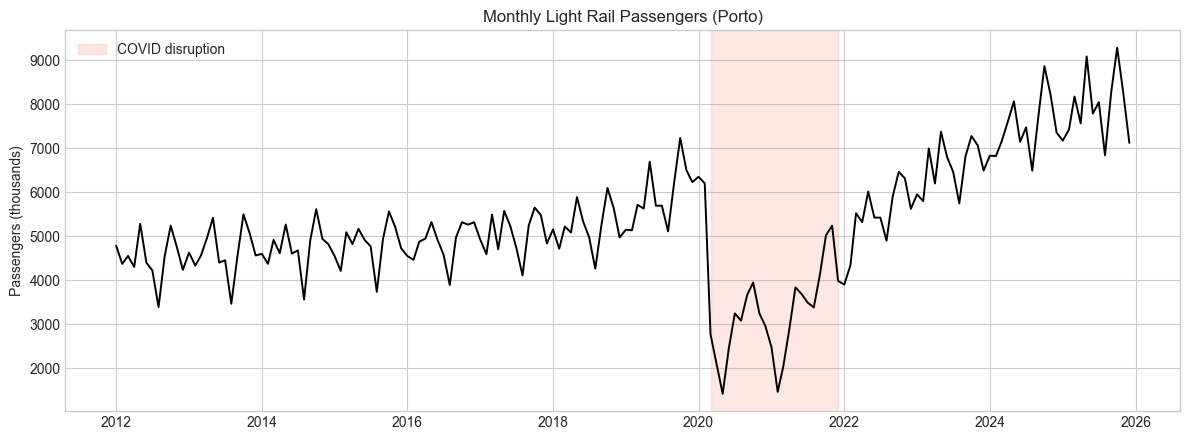

In [76]:

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(series.index, series.values, color='black', linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='tomato', alpha=0.15, label='COVID disruption')
ax.set_title('Monthly Light Rail Passengers (Porto)')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'eda_time_plot.png', dpi=300)
plt.show()


In [77]:

# Seasonal profile by month
month_profile = series.groupby(series.index.month).agg(['mean', 'median'])
month_profile.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_profile


,mean,median
Jan,5075.428571,4855.5
Feb,4877.357143,4530.5
Mar,5221.928571,5158.5
Apr,5055.888759,4956.5
May,5745.857143,5499.5
Jun,5201.285714,5072.5
Jul,5163.571429,4755.0
Aug,4428.642857,4004.0
Sep,5515.857143,5110.0
Oct,6221.285714,5635.5


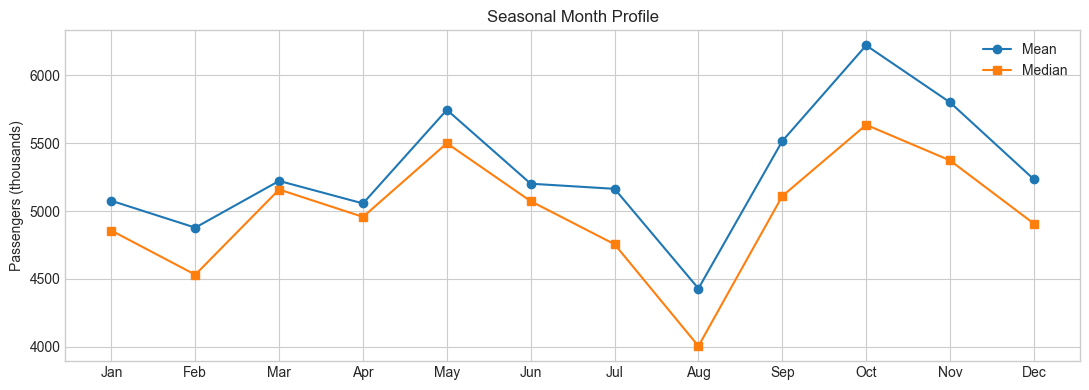

In [78]:

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(month_profile.index, month_profile['mean'], marker='o', label='Mean')
ax.plot(month_profile.index, month_profile['median'], marker='s', label='Median')
ax.set_title('Seasonal Month Profile')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'eda_month_profile.png', dpi=300)
plt.show()


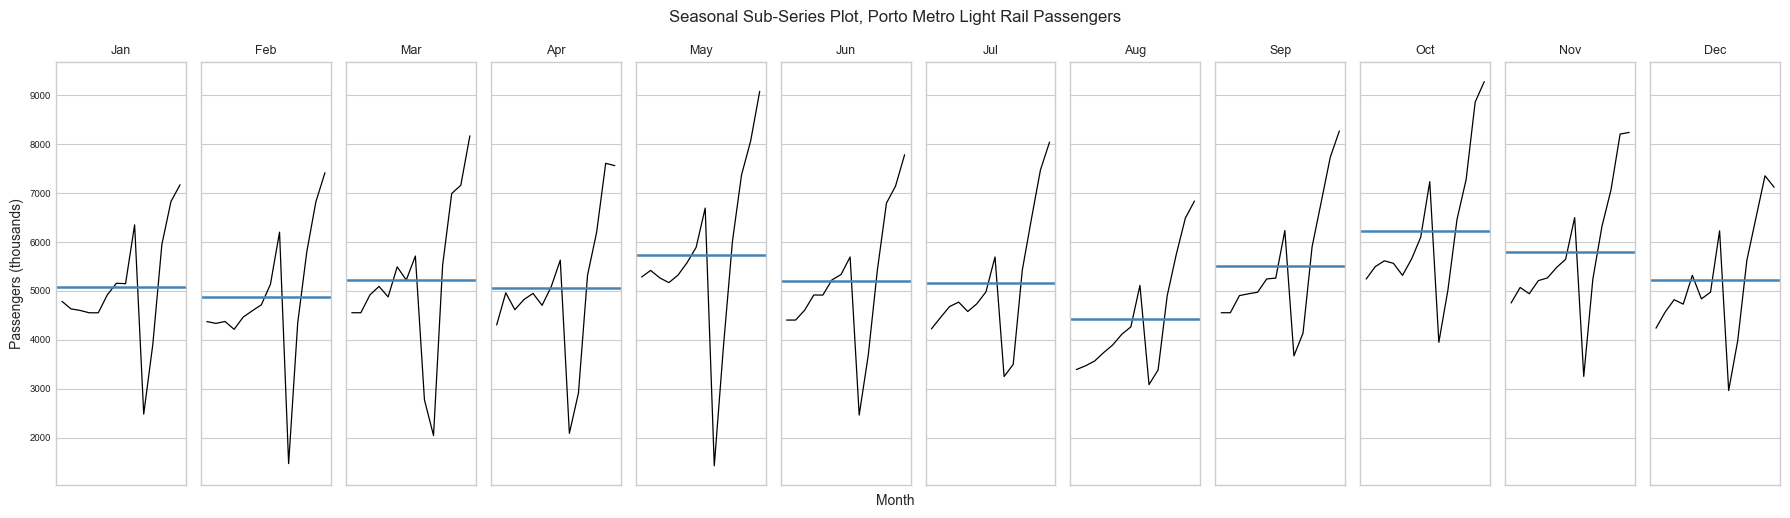

In [79]:
# Seasonal sub-series plot
# Each panel shows one calendar month across all years; horizontal bar = within-month mean
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 12, figsize=(18, 5), sharey=True)
fig.suptitle('Seasonal Sub-Series Plot, Porto Metro Light Rail Passengers', fontsize=12)

for i, (ax, mname) in enumerate(zip(axes, month_names), start=1):
    month_data = series[series.index.month == i]
    ax.plot(range(len(month_data)), month_data.values, color='black', linewidth=0.9)
    ax.axhline(month_data.mean(), color='steelblue', linewidth=1.8)
    ax.set_title(mname, fontsize=9)
    ax.set_xticks([])
    if i == 1:
        ax.set_ylabel('Passengers (thousands)')
    ax.tick_params(axis='y', labelsize=7)

fig.text(0.5, -0.01, 'Month', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_seasonal_subseries.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.2 COVID Adjustment and Model Counterfactuals

**Why adjust for COVID?** The 34-month COVID disruption (2020-03 to 2022-12) represents a regime break caused by mobility restrictions, not by underlying demand dynamics. When Holt-Winters models are trained on the raw series containing this shock, the optimiser returns degenerate boundary solutions: β→0 (trend frozen) and γ→0 (seasonality frozen). The COVID adjustment replaces the disruption window with a smooth counterfactual, giving the optimiser a consistent signal to learn the stable trend and seasonal structure.

**Three counterfactual variants** are constructed by fitting models on 2012–2018 and projecting 2019–2022:
- `series_hw`: COVID window replaced by the Holt-Winters forecast — used for `HW_Add` and `HW_Damp_Add` training.
- `series_stl_low`: COVID window replaced by STL + Holt (low smoothing: α=0.15, β=0.05) — used for `HW_Mul` training.
- `series_stl_high`: COVID window replaced by STL + Holt (high smoothing: α=0.65, β=0.30) — reference variant.

**Each variant replaces exactly 34 observations** — all other values remain as observed. Validation always uses original observed values.

--- ESTIMATION RESULTS: HOLT-WINTERS ---
                       ExponentialSmoothing Model Results                       
Dep. Variable:               Passengers   No. Observations:                   84
Model:             ExponentialSmoothing   SSE                        2064470.100
Optimized:                         True   AIC                            881.204
Trend:                         Additive   BIC                            920.097
Seasonal:                      Additive   AICC                           891.727
Seasonal Periods:                    12   Date:                 seg, 01 jun 2026
Box-Cox:                          False   Time:                         01:16:28
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level              1.4901e-08                alpha      

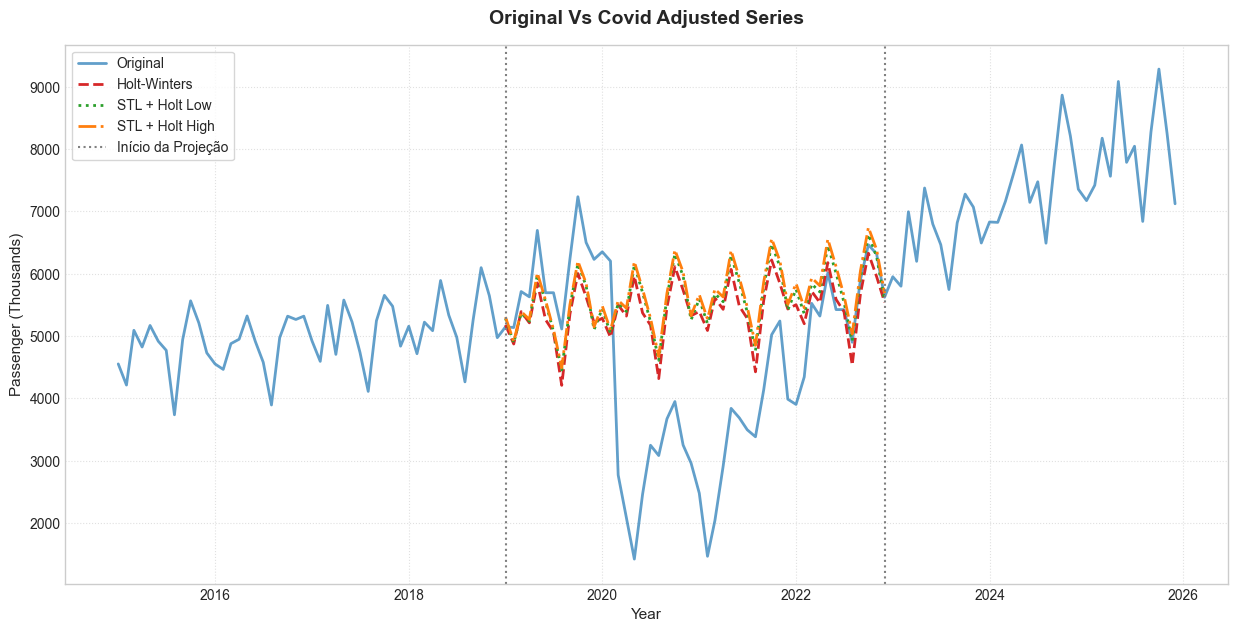

📸 Gráfico guardado com sucesso em: ..\outputs\figures\comparativo_modelos_covid.png
📊 Tabelas exportadas com sucesso em: ..\outputs\tables


In [80]:
# ==========================================
# 0. CONFIGURATION & DIRECTORY PATHS
# ==========================================
# Set up output directories
table_path = tables_dir
fig_path = fig_dir

# Create directories dynamically if they do not exist
table_path.mkdir(parents=True, exist_ok=True)
fig_path.mkdir(parents=True, exist_ok=True)


# ==========================================
# 1. ESTIMATION & PARAMETERS (2012-2018)
# ==========================================
# Train models on baseline data prior to 2019 projection window
treino = series.loc["2012-01-01":"2018-12-31"]

# Adjust Smoothing Exponential Holt-Winters model
modelo_hw = ExponentialSmoothing(
    treino, trend="add", seasonal="add", seasonal_periods=12
)
resultado_hw = modelo_hw.fit()

print("--- ESTIMATION RESULTS: HOLT-WINTERS ---")
print(resultado_hw.summary())

# Parameters alpha, beta e gamma:
parametros = resultado_hw.params
print("\nOptimum Parameters Estimated:")
print(f"Alpha (Level): {parametros['smoothing_level']:.4f}")
print(f"Beta (Trend): {parametros['smoothing_trend']:.4f}")
print(f"Gamma (Seazonality): {parametros['smoothing_seasonal']:.4f}")

# Finding seasonally adjusted data
df_smoothing = pd.DataFrame(
    {
        "Real_Observed": treino,
        "Smoothed_Fits": resultado_hw.fittedvalues,
        "Seasonally_Adjusted": treino / resultado_hw.season,
    },
    index=treino.index,
)

# Export smoothing report to CSV
df_smoothing.to_csv(table_path / 'HW_report.csv', index=True)


# ==========================================
# 2. GENERATE FORECASTS (2019-2022)
# ==========================================
teste_real = series.loc["2019-01-01":"2022-12-31"]
meses_a_prever = len(teste_real) 

# A) Holt-Winters Projection
previsao_hw = resultado_hw.forecast(steps=meses_a_prever)

# B) Decomposition STL + Holt Linear
stl_dinamico = STL(treino, period=12, robust=True).fit()
tendencia_treino = stl_dinamico.trend
sazonalidade_treino = stl_dinamico.seasonal

# Train Holt Linear only on the trend component
model_holt_low = Holt(tendencia_treino).fit(smoothing_level=0.15, smoothing_trend=0.05, optimized=False)
pred_holt_tendencia_low = model_holt_low.forecast(steps=meses_a_prever)

model_holt_high = Holt(tendencia_treino).fit(smoothing_level=0.65, smoothing_trend=0.30, optimized=False)
pred_holt_tendencia_high = model_holt_high.forecast(steps=meses_a_prever)

# Replicate Seasonality: Extract last 12 months and repeat to cover the gap
sazonalidade_ciclo_12 = sazonalidade_treino.iloc[-12:].values
repeticoes_necessarias = int(np.ceil(meses_a_prever / 12))
sazonalidade_futura = np.tile(sazonalidade_ciclo_12, repeticoes_necessarias)[:meses_a_prever]

# Recomposition (Predicted Trend + Replicated Historical Seasonality)
pred_holt_final_low = pred_holt_tendencia_low + sazonalidade_futura
pred_holt_final_high = pred_holt_tendencia_high + sazonalidade_futura


# ==========================================
# 3. ERROR METRICS
# ==========================================
def calcular_metricas(real, previsto):
    mape = np.abs((real - previsto) / real).mean() * 100
    rmse = np.sqrt(((real - previsto) ** 2).mean())
    return mape, rmse

mape_hw, rmse_hw = calcular_metricas(teste_real, previsao_hw)
mape_holt_low, rmse_holt_low = calcular_metricas(teste_real, pred_holt_final_low)
mape_holt_high, rmse_holt_high = calcular_metricas(teste_real, pred_holt_final_high)

print("\n--- FORECAST EVALUATION COMPARISON ---")
print(f"Holt-Winters       -> MAPE: {mape_hw:.2f}% | RMSE: {rmse_hw:.2f}")
print(f"STL + Holt (Low)   -> MAPE: {mape_holt_low:.2f}% | RMSE: {rmse_holt_low:.2f}")
print(f"STL + Holt (High)  -> MAPE: {mape_holt_high:.2f}% | RMSE: {rmse_holt_high:.2f}\n")


# ==========================================
# 4. CONSOLIDATE DATA & EXPORT TO CSV
# ==========================================
df_previsao_consolidado = pd.DataFrame({
    "Real_Observed": teste_real,
    
    "Forecast_HW": previsao_hw,
    "Error_HW_Pct": np.abs((teste_real - previsao_hw) / teste_real) * 100,
    
    "Forecast_Holt_Low": pred_holt_final_low,
    "Error_Holt_Low_Pct": np.abs((teste_real - pred_holt_final_low) / teste_real) * 100,
    
    "Forecast_Holt_High": pred_holt_final_high,
    "Error_Holt_High_Pct": np.abs((teste_real - pred_holt_final_high) / teste_real) * 100
}, index=teste_real.index)

# Save consolidated evaluation matrix to CSV
df_previsao_consolidado.to_csv(table_path / 'Forecast_Comparison.csv', index=True)


# ==========================================
# 5. COMPARATIVE PLOT
# ==========================================
# Focus visualization window from 2015 onwards
dados_reais_zoom = series.loc["2015-01-01":]

plt.figure(figsize=(15, 7))

# Actual Observed Data
plt.plot(dados_reais_zoom.index, dados_reais_zoom.values, label="Original", color="#1f77b4", linewidth=2, alpha=0.7)

# Model 1: Holt-Winters Counterfactual Curve
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_HW'], label="Holt-Winters", color="#d62728", linestyle="--", linewidth=2)

# Model 2: STL + Holt (Low Smoothing Curve)
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_Holt_Low'], label="STL + Holt Low", color="#2ca02c", linestyle=":", linewidth=2)

# Model 3: STL + Holt (High Smoothing Curve)
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_Holt_High'], label="STL + Holt High", color="#ff7f0e", linestyle="-.", linewidth=2)

# Structural break markers (Projection bounds)
plt.axvline(x=pd.to_datetime("2019-01-01"), color="gray", linestyle=":", linewidth=1.5, label="Início da Projeção")
plt.axvline(x=pd.to_datetime("2022-12-01"), color="gray", linestyle=":", linewidth=1.5)

# Plot formatting
plt.title("Original Vs Covid Adjusted Series", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Passenger (Thousands)", fontsize=11)
plt.legend(loc="upper left", fontsize=10, frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)

# Save and render visualization block
caminho_salvar_grafico = fig_path / "comparativo_modelos_covid.png"
plt.savefig(caminho_salvar_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Gráfico guardado com sucesso em: {caminho_salvar_grafico}")
print(f"📊 Tabelas exportadas com sucesso em: {table_path}")

### 3.3 COVID-Adjusted Series — Verification

All three adjusted series replace exactly **34 observations** (March 2020 to December 2022) with model counterfactuals. Outside this window, every value is identical to the original observed series. The counterfactual models were trained on 2012–2018 — a period of stable network operation — and projected forward through the disruption window, capturing the expected ridership trajectory in the absence of COVID restrictions.

In [81]:
# COVID window bounds
COVID_START = pd.Timestamp("2020-03-01")
COVID_END   = pd.Timestamp("2022-12-01")

# Align forecast index to proper MS DatetimeIndex
fc_index = pd.date_range(start="2019-01-01", periods=len(previsao_hw), freq="MS")
previsao_hw.index    = fc_index
pred_holt_final_low  = pd.Series(pred_holt_final_low.values,  index=fc_index)
pred_holt_final_high = pd.Series(pred_holt_final_high.values, index=fc_index)

# Extract only the COVID-window slice from each forecast
hw_covid   = previsao_hw.loc[COVID_START:COVID_END]
low_covid  = pred_holt_final_low.loc[COVID_START:COVID_END]
high_covid = pred_holt_final_high.loc[COVID_START:COVID_END]

# Build three adjusted series: original everywhere, COVID window replaced by model counterfactual
series_hw       = series.copy().astype(float)
series_stl_low  = series.copy().astype(float)
series_stl_high = series.copy().astype(float)

series_hw.loc[COVID_START:COVID_END]       = hw_covid.values
series_stl_low.loc[COVID_START:COVID_END]  = low_covid.values
series_stl_high.loc[COVID_START:COVID_END] = high_covid.values

# series_adj = HW-adjusted series; used as default downstream reference
series_adj = series_hw.copy()

# Verification
print("=== COVID-Adjusted Series - Observations Replaced ===")
for name, s in [("series_hw", series_hw), ("series_stl_low", series_stl_low), ("series_stl_high", series_stl_high)]:
    n_changed = int((s != series).sum())
    print(f"  {name}: {n_changed} obs replaced  (COVID window = {len(hw_covid)} months)")

# Save all three to CSV for traceability
pd.DataFrame({
    "Original":        series,
    "series_hw":       series_hw,
    "series_stl_low":  series_stl_low,
    "series_stl_high": series_stl_high,
}).to_csv(tables_dir / "covid_adjusted_series.csv")
print("Saved: outputs/tables/covid_adjusted_series.csv")


=== COVID-Adjusted Series - Observations Replaced ===
  series_hw: 34 obs replaced  (COVID window = 34 months)
  series_stl_low: 34 obs replaced  (COVID window = 34 months)
  series_stl_high: 34 obs replaced  (COVID window = 34 months)
Saved: outputs/tables/covid_adjusted_series.csv


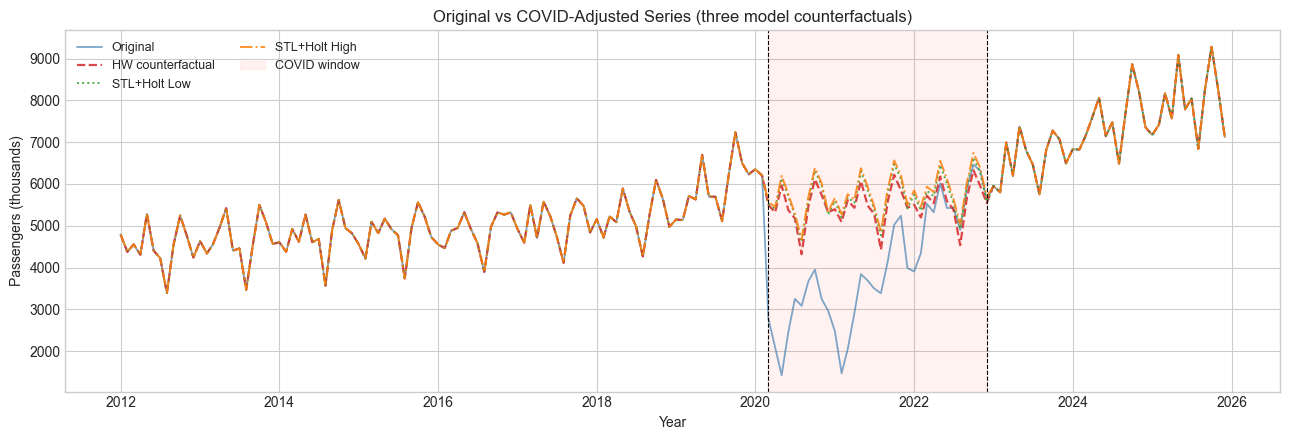

In [82]:
# Full-series plot: original vs all three COVID-adjusted series
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(series.index, series.values,
        color="steelblue", linewidth=1.3, alpha=0.7, label="Original")
ax.plot(series_hw.index, series_hw.values,
        color="#d62728", linewidth=1.6, linestyle="--", alpha=0.85, label="HW counterfactual")
ax.plot(series_stl_low.index, series_stl_low.values,
        color="#2ca02c", linewidth=1.4, linestyle=":",  alpha=0.85, label="STL+Holt Low")
ax.plot(series_stl_high.index, series_stl_high.values,
        color="#ff7f0e", linewidth=1.4, linestyle="-.", alpha=0.85, label="STL+Holt High")
ax.axvspan(COVID_START, COVID_END, color="tomato", alpha=0.08, label="COVID window")
ax.axvline(COVID_START, color="black", linestyle="--", linewidth=0.8)
ax.axvline(COVID_END,   color="black", linestyle="--", linewidth=0.8)
ax.set_title("Original vs COVID-Adjusted Series (three model counterfactuals)")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(fig_dir / "eda_covid_model_adjusted.png", dpi=300)
plt.show()


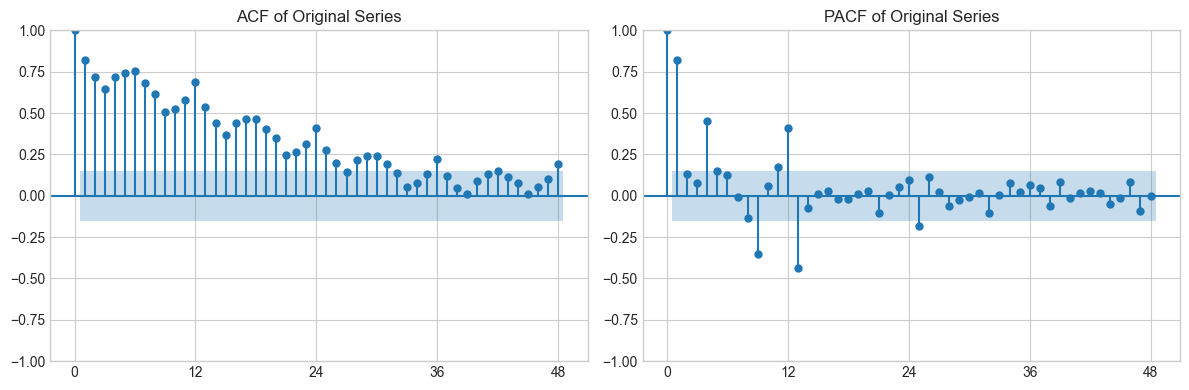

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot ACF and PACF
plot_acf(series_hw, lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF of Original Series')

plot_pacf(series_hw, lags=48, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Original Series')

# Set x-axis ticks every 12 lags for both plots
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))

plt.tight_layout()
plt.savefig(fig_dir / 'eda_acf_pacf_raw.png', dpi=300)
plt.show()

In [84]:
# train is always built from series_hw (COVID window replaced by HW counterfactual)
# series_hw is defined in EDA Section 3 (covid_adj_code cell).
# After the EDA chapter series_hw is the canonical series used for all model fitting.
train = series_hw.loc[:train_end]
valid = series.loc[val_start:val_end]   # validation always uses original observed values

assert len(valid) == 12, "Validation window must be exactly 12 months."
print(f"Train (series_hw): {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"Validation (original): {valid.index.min().date()} -> {valid.index.max().date()} ({len(valid)} obs)")

Train (series_hw): 2012-01-01 -> 2024-12-01 (156 obs)
Validation (original): 2025-01-01 -> 2025-12-01 (12 obs)


## 4. Smoothing and Decomposition Methods

### 4.1 STL Decomposition

STL (Seasonal-Trend decomposition using Loess) is applied to the training series (`train` = `series_hw`, 2012–2024). `robust=True` is used to down-weight any remaining outliers at the COVID adjustment boundaries. STL is preferred over classical additive decomposition because it allows the seasonal component to evolve slowly over time and handles irregular observations without distortion.

**Decomposition results** on the training series:
- The seasonal component confirms a strongly additive structure: August factor = −1,087, October = +783, May = +630.
- Seasonal standard deviation: **466 thousand** — nearly twice the remainder std of **243 thousand**. This ratio confirms that the seasonal pattern explains far more variation than the irregular component, making the series highly amenable to seasonal forecasting methods.
- The largest remainder excursions occur at the COVID adjustment boundary months (2020-03 and 2022-12), confirming the counterfactual correction was effective but did not eliminate all edge artefacts.

**Why additive STL?** The seasonal amplitude does not scale proportionally with the trend level — the post-COVID seasonal range is similar in absolute magnitude to the pre-COVID range despite the level being higher. An additive seasonal component is therefore the appropriate specification.

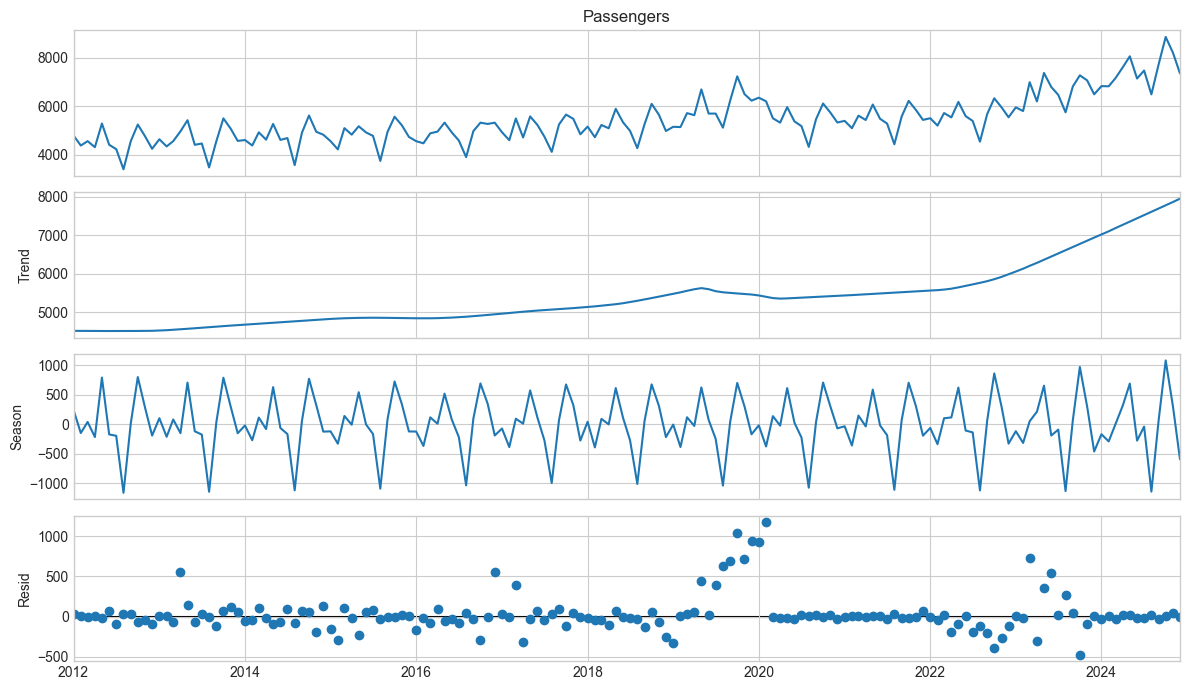

In [85]:
# train is series_hw-based (COVID-adjusted) — see train/valid split cell

stl = STL(train, period=SEASONAL_PERIOD, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(12, 7)
plt.tight_layout()
plt.savefig(fig_dir / 'stl_decomposition_train.png', dpi=300)
plt.show()

stl_components = pd.DataFrame({
    'Observed': train,
    'Trend': stl.trend,
    'Seasonal': stl.seasonal,
    'Remainder': stl.resid,
    'Seasonally_Adjusted': train - stl.seasonal
})
stl_components.to_csv(tables_dir / 'stl_components_train.csv')


### 4.2 Decomposition-Based Forecast: STL + Holt

**Method**: STL decomposes the training series into trend, seasonal, and remainder components. The seasonally-adjusted series (observed minus seasonal) is then modelled with Holt's linear method (no seasonal term), which captures the residual trend. The 12-month forecast is reconstructed by adding the projected trend back to the last 12 seasonal factors from training.

**Why this approach?** Decomposition-based forecasting separates the structural components so each can be modelled with its most appropriate method. Holt's linear method is well-suited for trend-only series; wrapping the seasonal factors back in is a principled way to produce a full forecast without requiring the seasonal model to also capture trend dynamics.

**Applicability to this data**: The STL seasonal component is stable and additive, which means the wrap-around of the last 12 seasonal factors is a reasonable approximation. The limitation is that the Holt trend extrapolation is sensitive to recent slope — the steep 2022–2023 recovery led to an over-projection into 2024–2025, pulling the STL+ETS forecast above the moderating actual ridership.

**2025 validation result**: MAPE = 5.70%, RMSE = 515, MASE = 0.90 — worse than all three Holt-Winters variants. The negative ME (−398) reveals a systematic downward bias: the Holt trend projected the recovery slope forward past the actual moderation. This is the primary limitation of decomposition forecasting when trend dynamics change near the forecast origin.

In [86]:
# train is series_hw-based (COVID-adjusted) — see train/valid split cell
# STL + ETS decomposition-based forecast
# Step 1: STL decomposition on training data (robust=True to down-weight COVID outliers)
stl_for_fc = STL(train, period=SEASONAL_PERIOD, robust=True).fit()
seasonal_component = stl_for_fc.seasonal           # shape: (len(train),)
sa_series = train - seasonal_component              # seasonally-adjusted

# Step 2: Fit simple exponential smoothing with trend (Holt, no seasonal) on SA series
from statsmodels.tsa.holtwinters import Holt
holt_sa = Holt(sa_series, damped_trend=False).fit(optimized=True)
sa_forecast = holt_sa.forecast(HORIZON)

# Step 3: Re-add seasonal factors — wrap-around from last 12 months of training
last_seasonal = seasonal_component.iloc[-SEASONAL_PERIOD:].values
stl_ets_pred = pd.Series(
    sa_forecast.values + last_seasonal,
    index=pd.date_range(start=f'{VALIDATION_YEAR}-01-01', periods=HORIZON, freq='MS')
)

print('STL+ETS Decomposition Forecast (2025 validation):')
print(pd.DataFrame({'Actual': valid.values, 'STL_ETS': stl_ets_pred.values}, index=valid.index).round(1))

# Interpret the seasonal component
print('\nSTL Seasonal Component Summary (by month):')
stl_seasonal_by_month = pd.DataFrame({
    'month': stl_for_fc.seasonal.index.month,
    'seasonal': stl_for_fc.seasonal.values
}).groupby('month')['seasonal'].mean()
stl_seasonal_by_month.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(stl_seasonal_by_month.round(1))
print(f'\nLargest negative seasonal factor: {stl_seasonal_by_month.idxmin()} ({stl_seasonal_by_month.min():.1f})')
print(f'Largest positive seasonal factor: {stl_seasonal_by_month.idxmax()} ({stl_seasonal_by_month.max():.1f})')
print(f'Seasonal std: {stl_for_fc.seasonal.std():.2f}  |  Remainder std: {stl_for_fc.resid.std():.2f}')
print('Note: remainder std ≈ seasonal std suggests the irregular component is as variable as seasonality.')


STL+ETS Decomposition Forecast (2025 validation):
            Actual  STL_ETS
Date                       
2025-01-01  7174.0   7827.1
2025-02-01  7421.0   7765.2
2025-03-01  8175.0   8116.0
2025-04-01  7565.0   8489.5
2025-05-01  9085.0   8921.0
2025-06-01  7788.0   8014.2
2025-07-01  8046.0   8310.1
2025-08-01  6840.0   7268.3
2025-09-01  8274.0   8538.0
2025-10-01  9284.0   9607.1
2025-11-01  8244.0   8886.2
2025-12-01  7123.0   8049.5

STL Seasonal Component Summary (by month):
Jan     -25.1
Feb    -318.3
Mar      97.3
Apr      11.6
May     630.0
Jun     -39.7
Jul    -181.6
Aug   -1087.2
Sep      62.4
Oct     782.5
Nov     313.3
Dec    -235.1
Name: seasonal, dtype: float64

Largest negative seasonal factor: Aug (-1087.2)
Largest positive seasonal factor: Oct (782.5)
Seasonal std: 466.25  |  Remainder std: 243.04
Note: remainder std ≈ seasonal std suggests the irregular component is as variable as seasonality.


In [87]:
# train = series_hw[:train_end]  (set in the train/valid split cell)
# HW_Mul uses train_stl_low to provide a second adjusted variant.

train_stl_low = series_stl_low.loc[:pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")]

# Baseline: seasonal naive from original observed train
seasonal_naive_pred = series.loc[:pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")].iloc[-SEASONAL_PERIOD:].values

# Holt-Winters additive -- train (series_hw based)
hw_add = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_add_pred = hw_add.forecast(HORIZON)

# Holt-Winters multiplicative -- STL+Holt Low-adjusted data
hw_mul = ExponentialSmoothing(
    train_stl_low, trend="add", seasonal="mul", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_mul_pred = hw_mul.forecast(HORIZON)

# Damped-trend HW additive -- train (series_hw based)
hw_dmp = ExponentialSmoothing(
    train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_dmp_pred = hw_dmp.forecast(HORIZON)

print("Smoothing models fitted.")
print(f"  train (series_hw): {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"  train_stl_low:     {train_stl_low.index.min().date()} -> {train_stl_low.index.max().date()} ({len(train_stl_low)} obs)")


Smoothing models fitted.
  train (series_hw): 2012-01-01 -> 2024-12-01 (156 obs)
  train_stl_low:     2012-01-01 -> 2024-12-01 (156 obs)


In [88]:
# Estimation results for smoothing methods (rubric requirement)
smoothing_estimation = pd.DataFrame([
    {
        'Model': 'HW_Add',
        'alpha_level': hw_add.params.get('smoothing_level', np.nan),
        'beta_trend': hw_add.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_add.params.get('smoothing_seasonal', np.nan),
        'phi_damping': np.nan,
        'SSE': hw_add.sse,
    },
    {
        'Model': 'HW_Mul',
        'alpha_level': hw_mul.params.get('smoothing_level', np.nan),
        'beta_trend': hw_mul.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_mul.params.get('smoothing_seasonal', np.nan),
        'phi_damping': np.nan,
        'SSE': hw_mul.sse,
    },
    {
        'Model': 'HW_Damp_Add',
        'alpha_level': hw_dmp.params.get('smoothing_level', np.nan),
        'beta_trend': hw_dmp.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_dmp.params.get('smoothing_seasonal', np.nan),
        'phi_damping': hw_dmp.params.get('damping_trend', np.nan),
        'SSE': hw_dmp.sse,
    },
])
smoothing_estimation.to_csv(tables_dir / 'smoothing_estimation_results.csv', index=False)
print(smoothing_estimation.to_string(index=False))

# --- Boundary solution commentary ---
print('\n--- Boundary Parameter Diagnostics ---')
for _, row in smoothing_estimation.iterrows():
    flags = []
    if abs(row['beta_trend']) < 1e-6:
        flags.append('β=0 (frozen trend: trend component never updated after initialisation)')
    if abs(row['gamma_seasonal']) < 1e-6:
        flags.append('γ=0 (frozen seasonality: seasonal factors set at init and never updated)')
    if abs(row['alpha_level'] - 1.0) < 1e-4:
        flags.append('α=1 (random-walk level: all weight on most recent observation, zero memory)')
    if flags:
        print(f"  {row['Model']}: " + '; '.join(flags))
    else:
        print(f"  {row['Model']}: no boundary solutions detected")

print("""
NOTE: β=0 and γ=0 are boundary/corner solutions from the parameter optimiser.
They indicate the model cannot simultaneously adapt to the COVID disruption and
the post-recovery growth. With frozen trend and frozen seasonality, HW_Add and
HW_Mul are simpler models than their specification implies. For HW_Mul, α=1.0
means the level is always the most recent observation (random-walk level).
Prediction intervals from these models may be unreliable due to misspecification.
HW_Damp_Add is included as an alternative that constrains trend growth via φ.
""")


      Model  alpha_level  beta_trend  gamma_seasonal  phi_damping          SSE
     HW_Add     0.560632         0.0             0.0          NaN 7.712271e+06
     HW_Mul     0.458206         0.0             0.0          NaN 8.406752e+06
HW_Damp_Add     0.564824         0.0             0.0        0.995 7.817707e+06

--- Boundary Parameter Diagnostics ---
  HW_Add: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)
  HW_Mul: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)
  HW_Damp_Add: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)

NOTE: β=0 and γ=0 are boundary/corner solutions from the parameter optimiser.
They indicate the model cannot simultaneously adapt to the COVID disruption and
the post-recove

## 5. SARIMA Model Development

### 5.1 SARIMA — Methodology and Identification

SARIMA extends ARIMA to capture both non-seasonal and seasonal autocorrelation. We apply it to `log(train)` for two reasons: (1) the log transformation stabilises the level-dependent variance observed in the EDA, and (2) back-transforming forecasts via exponentiation produces asymmetric prediction intervals consistent with a log-normal error structure. **All test-set errors are computed on the original passenger scale after exponentiation**, so accuracy comparisons across methods are valid.

**Differencing order (d=1, D=1, s=12)**:
- d=1: removes the non-seasonal trend (slow ACF decay in the raw log series).
- D=1: removes the seasonal unit root (persistent spikes at lags 12, 24, 36 in the ACF).
- These orders are identified visually from the ACF/PACF of the log series, consistent with standard practice for monthly transport data.

**Shortlist construction**: Five candidates span both seasonal MA (SMA(1), suggested by the dominant ACF spike at lag 12 after differencing) and seasonal AR (SAR(1)) structures, plus mixed seasonal ARMA. Non-seasonal orders (p=0,1,3; q=0,1) are identified from the ACF/PACF of the doubly-differenced log series.

**AICc** (small-sample corrected AIC) is reported alongside AIC and BIC as the primary selection criterion, since sample size (n=156 after differencing) is moderate relative to the number of parameters. AICc adds the correction term 2k(k+1)/(n−k−1) to penalise overparameterisation more strongly at smaller sample sizes.

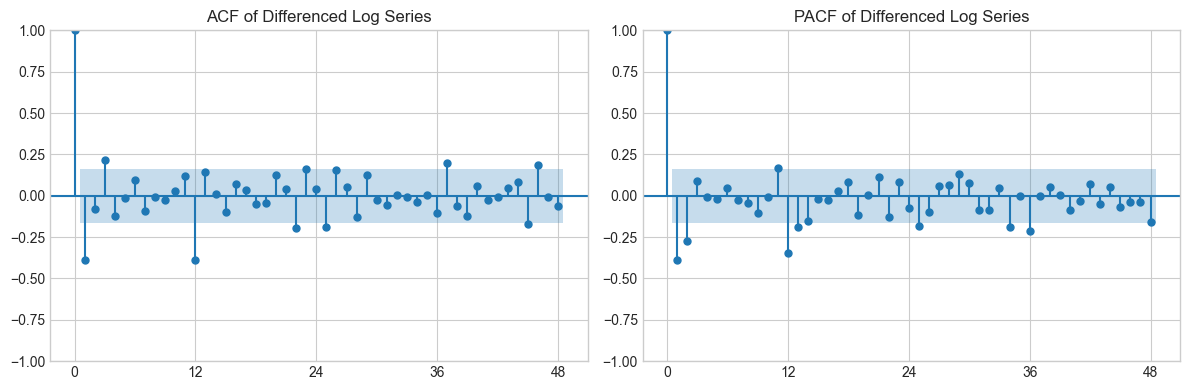

In [89]:
# Transformation and differencing discussion support
train_log = np.log(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(train_log.diff().dropna().diff(12).dropna(), lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF of Differenced Log Series')

plot_pacf(train_log.diff().dropna().diff(12).dropna(), lags=48, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Differenced Log Series')

# Set x-axis ticks every 12 lags for both plots
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))

plt.tight_layout()
plt.savefig(fig_dir / 'sarima_identification_acf_pacf.png', dpi=300)
plt.show()

In [90]:
# Shortlist: original SMA-only models + P>0 candidates to test seasonal AR structure
sarima_shortlist = {
    'SARIMA_011_011': ((0, 1, 1), (0, 1, 1, 12)),
    'SARIMA_111_011': ((1, 1, 1), (0, 1, 1, 12)),   # SMA(2) to test richer seasonal MA structure
    'SARIMA_310_011': ((3, 1, 0), (0, 1, 1, 12)),
    'SARIMA_011_110': ((0, 1, 1), (1, 1, 0, 12)),   # SAR(1) alternative
    'SARIMA_111_111': ((1, 1, 1), (1, 1, 1, 12)),   # mixed seasonal structure
}

sarima_results = []
sarima_validation_forecasts = {}

def aicc(aic, k, n):
    """AICc small-sample correction."""
    if n - k - 1 <= 0:
        return np.nan
    return aic + (2 * k * (k + 1)) / (n - k - 1)

for name, (order, seasonal_order) in sarima_shortlist.items():
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)

        resid = fit.resid.dropna()
        model_df = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
        lb = acorr_ljungbox(resid, lags=[12, 24], model_df=model_df, return_df=True)

        fc = fit.get_forecast(steps=HORIZON)
        mean_fc = np.exp(fc.predicted_mean)
        ci = fc.conf_int(alpha=0.05)
        lo = np.exp(ci.iloc[:, 0])
        hi = np.exp(ci.iloc[:, 1])

        sarima_validation_forecasts[name] = {
            'fit': fit,
            'mean': mean_fc,
            'low': lo,
            'high': hi,
        }

        n_obs = len(train_log)
        k_params = fit.df_model
        sarima_results.append({
            'Model': name,
            'Order': str(order),
            'Seasonal_Order': str(seasonal_order),
            'AIC': fit.aic,
            'AICc': aicc(fit.aic, k_params, n_obs),
            'BIC': fit.bic,
            'LjungBox_p_12': lb.loc[12, 'lb_pvalue'] if 12 in lb.index else np.nan,
            'LjungBox_p_24': lb.loc[24, 'lb_pvalue'] if 24 in lb.index else np.nan,
        })
    except Exception as e:
        sarima_results.append({
            'Model': name,
            'Order': str(order),
            'Seasonal_Order': str(seasonal_order),
            'AIC': np.nan,
            'AICc': np.nan,
            'BIC': np.nan,
            'LjungBox_p_12': np.nan,
            'LjungBox_p_24': np.nan,
        })

sarima_table = pd.DataFrame(sarima_results).sort_values('AIC')
sarima_table.to_csv(tables_dir / 'sarima_shortlist_aic_bic.csv', index=False)
sarima_table



,Model,Order,Seasonal_Order,AIC,AICc,BIC,LjungBox_p_12,LjungBox_p_24
2,SARIMA_310_011,"(3, 1, 0)","(0, 1, 1, 12)",-417.758314,-417.358314,-403.420642,7.526258e-07,0.000692
0,SARIMA_011_011,"(0, 1, 1)","(0, 1, 1, 12)",-414.368279,-414.210385,-405.788842,1.202732e-04,0.037348
1,SARIMA_111_011,"(1, 1, 1)","(0, 1, 1, 12)",-412.629049,-412.364149,-401.189800,5.318109e-05,0.025535
4,SARIMA_111_111,"(1, 1, 1)","(1, 1, 1, 12)",-406.001940,-405.601940,-391.702878,4.353046e-05,0.025734
3,SARIMA_011_110,"(0, 1, 1)","(1, 1, 0, 12)",-404.352476,-404.194581,-395.726884,1.242027e-02,0.383287


In [91]:
# Model coefficients for best-AIC SARIMA model
best_sarima_name = sarima_table.iloc[0]['Model']
best_fit = sarima_validation_forecasts[best_sarima_name]['fit']

# Save coefficient table
coef_df = pd.DataFrame({
    'coef':      best_fit.params,
    'std_err':   best_fit.bse,
    't_stat':    best_fit.tvalues,
    'p_value':   best_fit.pvalues,
    'ci_lower':  best_fit.conf_int().iloc[:, 0],
    'ci_upper':  best_fit.conf_int().iloc[:, 1],
})
coef_df.to_csv(tables_dir / 'sarima_best_coefficients.csv')
display(coef_df.round(4))


,coef,std_err,t_stat,p_value,ci_lower,ci_upper
ar.L1,-0.4982,0.0639,-7.7978,0.0000,-0.6235,-0.3730
ar.L2,-0.2642,0.0748,-3.5325,0.0004,-0.4108,-0.1176
ar.L3,0.1193,0.0888,1.3424,0.1795,-0.0549,0.2934
ma.S.L12,-0.7286,0.1138,-6.4017,0.0000,-0.9517,-0.5055
sigma2,0.0021,0.0002,11.8487,0.0000,0.0018,0.0024


### 5.3 SARIMA — Residual Diagnostics and Ljung-Box Assessment

The four-panel diagnostic plot (standardised residuals, ACF, Ljung-Box p-values, Q-Q) is shown for each of the five shortlisted SARIMA models.

**All five shortlisted SARIMA models fail the Ljung-Box white-noise test** at lag 12. The bar charts display p-values at lags 1–45; bars below the 5% threshold (red) indicate significant residual autocorrelation:

| Model | AICc | LB p(12) | LB p(24) |
|---|---:|---:|---:|
| **SARIMA_310_011** | **−417.4** | 7.5e-07 | 6.9e-04 |
| SARIMA_011_011 | −414.2 | 1.2e-04 | 0.037 |
| SARIMA_111_011 | −412.4 | 5.3e-05 | 0.026 |
| SARIMA_111_111 | −405.6 | 4.4e-05 | 0.026 |
| SARIMA_011_110 | −404.2 | 0.012 | 0.383 |

This is a direct consequence of the COVID structural break. The 34-month disruption injects concentrated autocorrelation at seasonal lags that standard ARIMA differencing (d=1, D=1) cannot absorb. The failure is consistent across all specifications.

**Selected model by AIC**: SARIMA(3,1,0)(0,1,1,12) — AICc = −417.4. Coefficients:
- ar.L1 = −0.498 (p<0.001), ar.L2 = −0.264 (p<0.001), ar.L3 = 0.119 (p=0.18, not significant)
- ma.S.L12 = −0.729 (p<0.001)

The non-significant ar.L3 suggests a more parsimonious AR(2) specification could be considered, but AR(3) is retained as the AIC-best model.

**Consequences for inference**:
- **Point forecasts** remain valid for comparison purposes — test-set accuracy is evaluated against observed values regardless of residual structure.
- **Prediction intervals** are derived under the white-noise assumption, which is violated; they should be treated as approximate rather than calibrated 95% PIs.

A **prediction interval** quantifies uncertainty about a single future observation; a **confidence interval** quantifies uncertainty about the mean. The intervals in the forecast tables are prediction intervals — wider than CIs at the same nominal level.

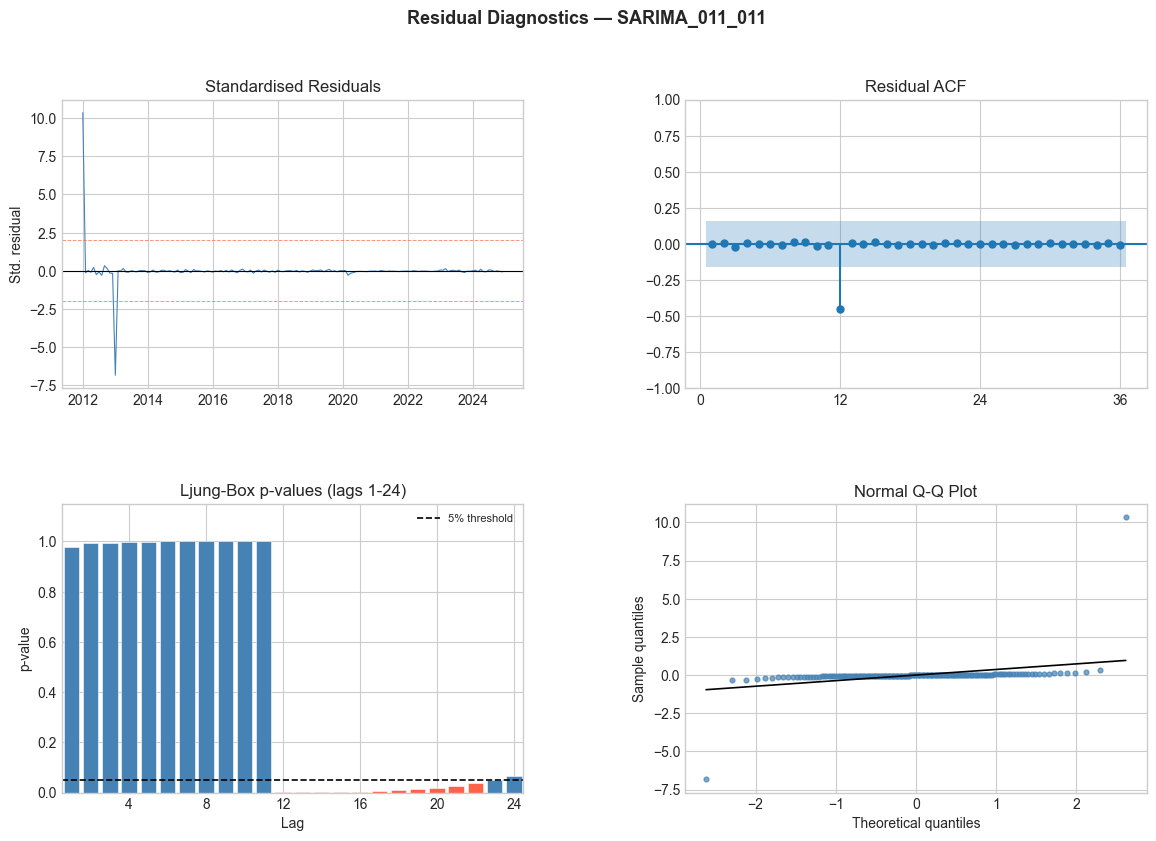

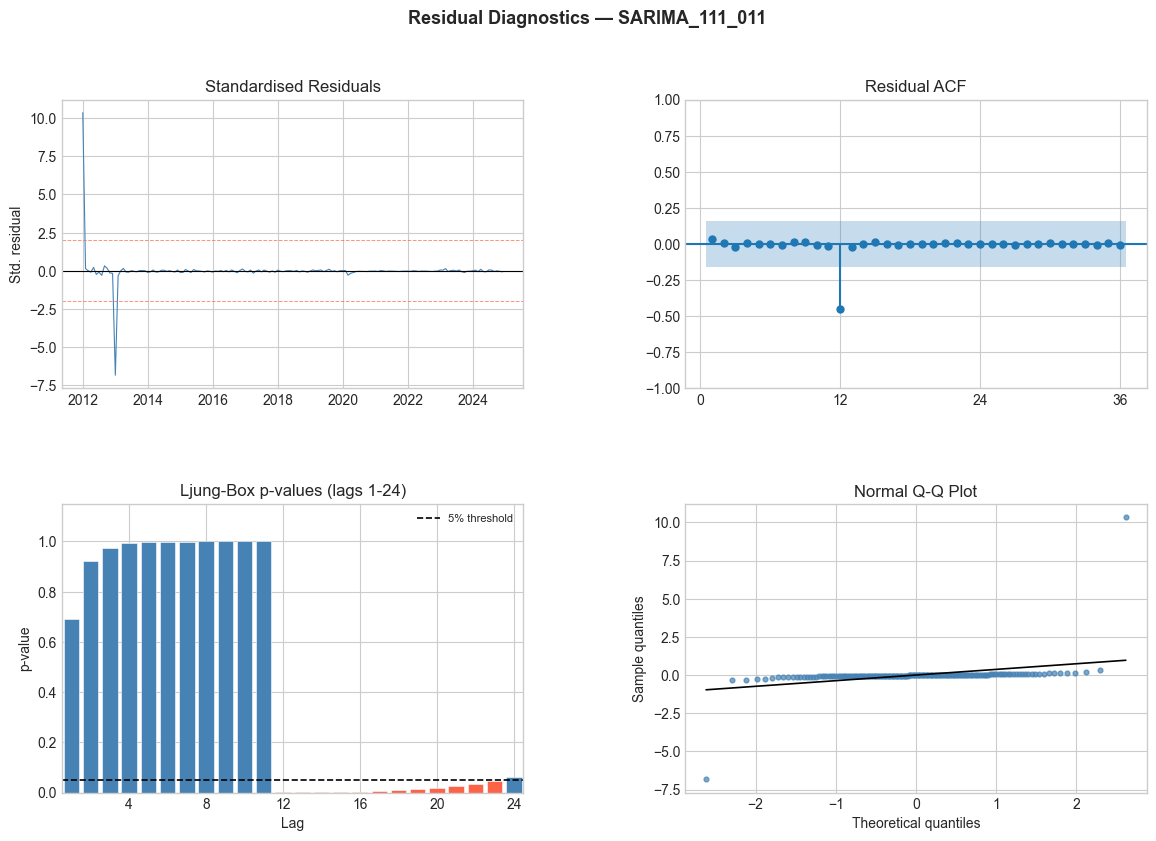

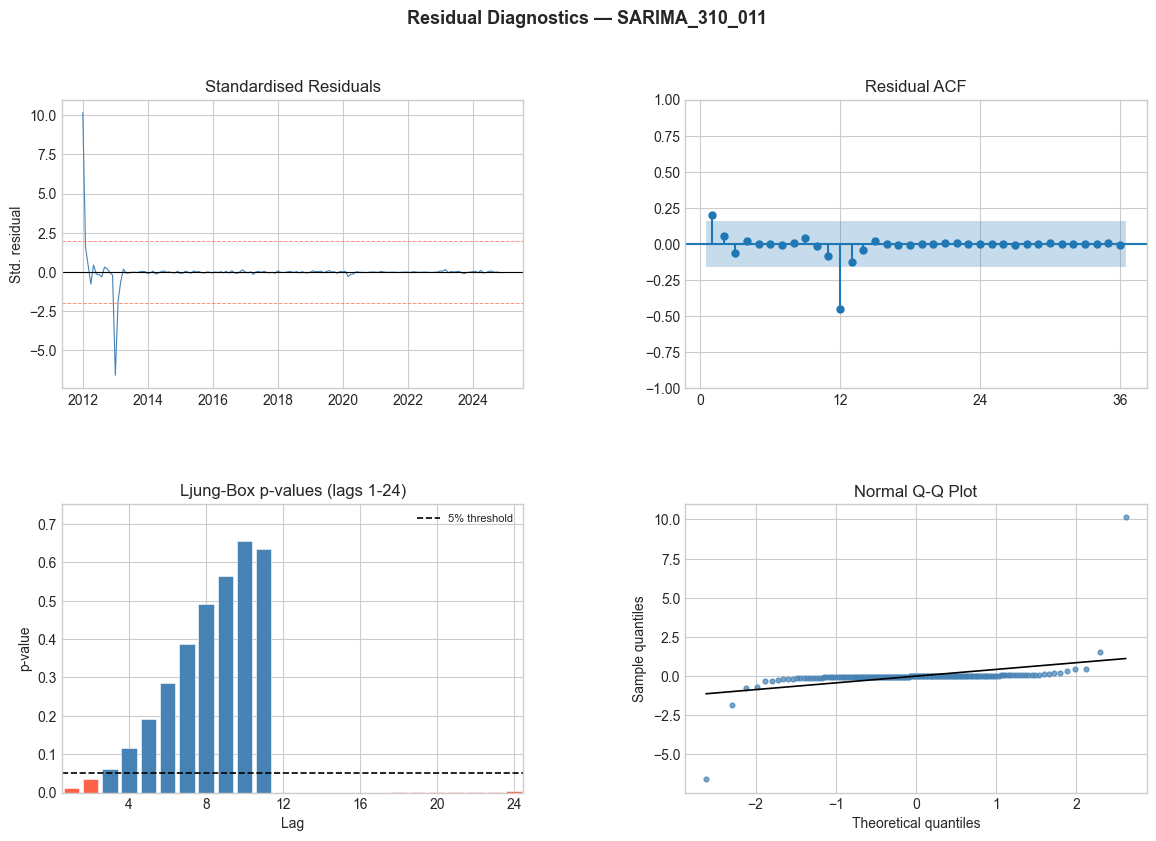

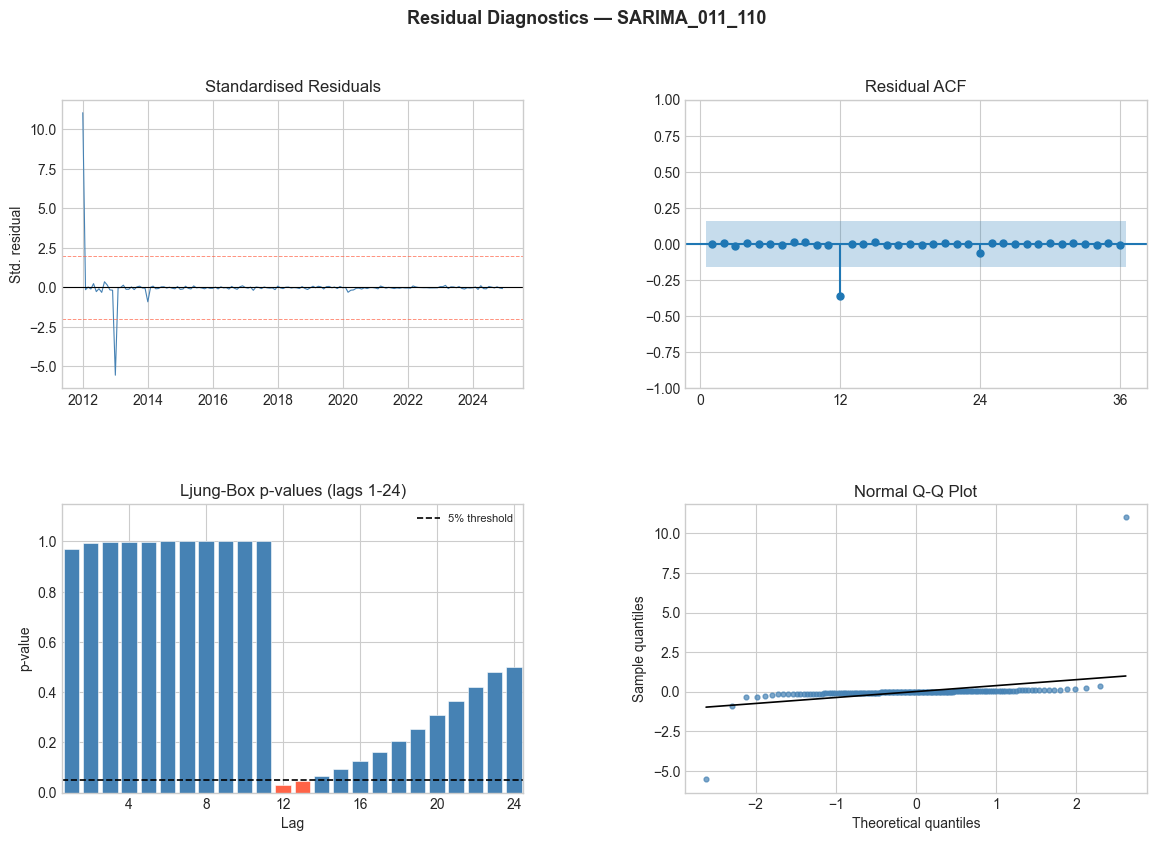

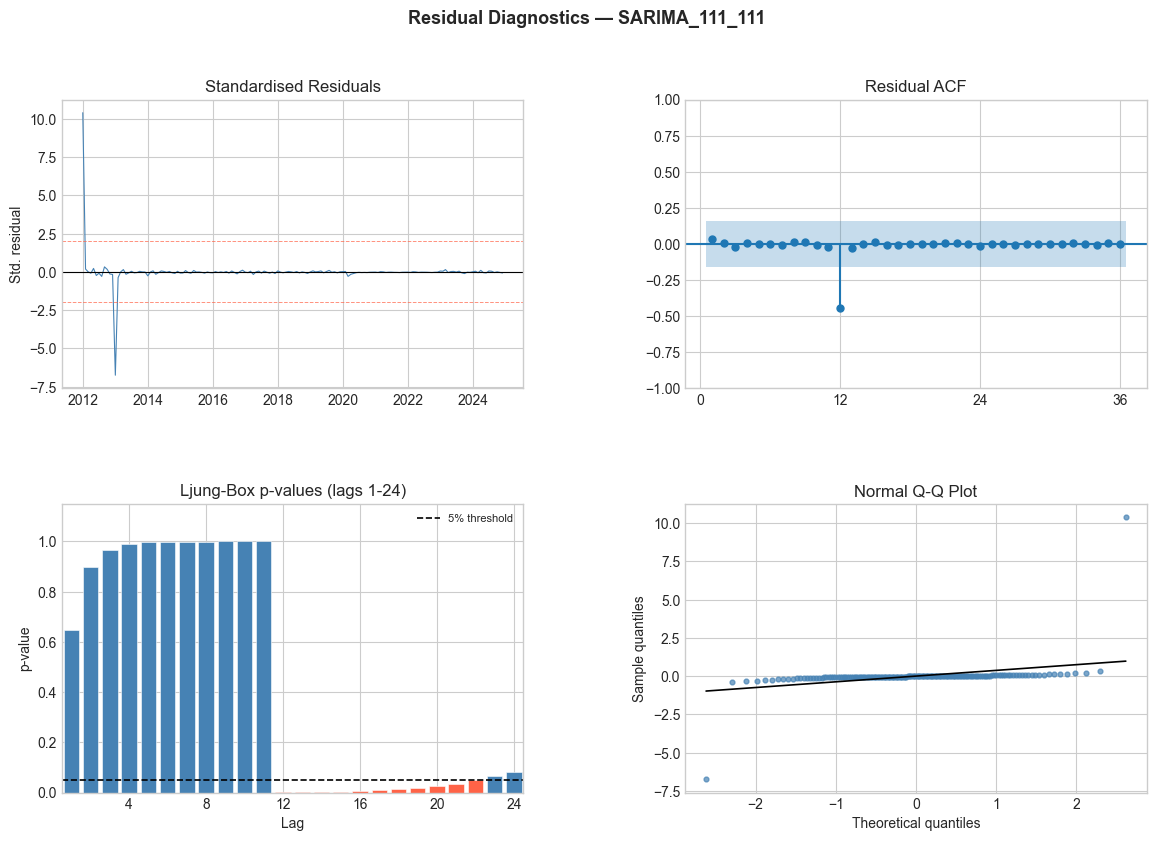

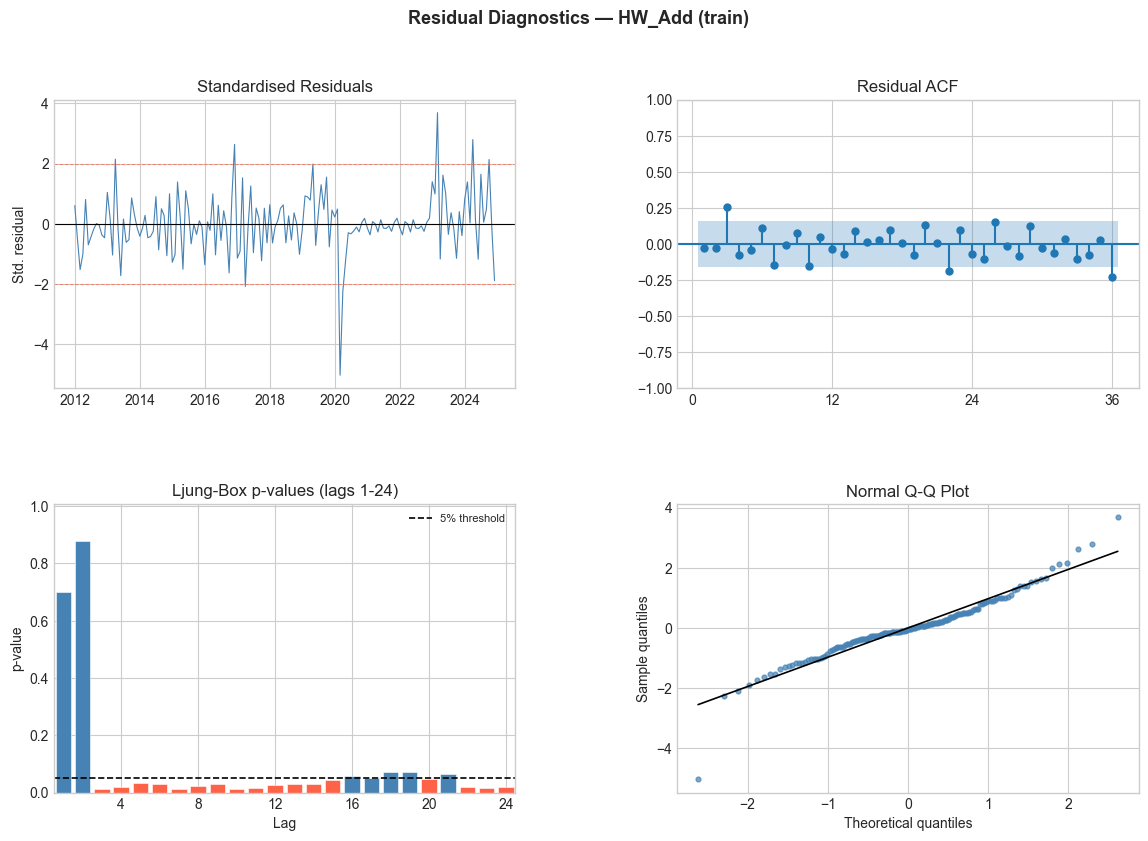

In [92]:
def plot_residual_diagnostics(resid, model_name, save_path):
    """Four-panel residual diagnostic plot: residuals, ACF, Ljung-Box p-values, Q-Q."""
    resid = resid.dropna()
    std_resid = (resid - resid.mean()) / resid.std()

    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # 1. Standardised residual time plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(resid.index if hasattr(resid, 'index') else range(len(resid)),
             std_resid, color='steelblue', linewidth=0.8)
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axhline(2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.axhline(-2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.set_title('Standardised Residuals')
    ax1.set_ylabel('Std. residual')

    # 2. Residual ACF
    ax2 = fig.add_subplot(gs[0, 1])
    plot_acf(resid, lags=36, ax=ax2, zero=False, bartlett_confint=False)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax2.set_title('Residual ACF')

    # 3. Ljung-Box p-values (lags 1-24)
    ax3 = fig.add_subplot(gs[1, 0])
    lb_lags = list(range(1, 25))
    lb_result = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
    lb_pvals = lb_result['lb_pvalue'].values
    colors = ['tomato' if p < 0.05 else 'steelblue' for p in lb_pvals]
    ax3.bar(lb_lags, lb_pvals, color=colors, edgecolor='white', linewidth=0.4)
    ax3.axhline(0.05, color='black', linestyle='--', linewidth=1.2, label='5% threshold')
    ax3.set_xlim(0.5, 24.5)
    ax3.set_ylim(0, max(0.12, lb_pvals.max() * 1.15))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax3.set_title('Ljung-Box p-values (lags 1-24)')
    ax3.set_xlabel('Lag')
    ax3.set_ylabel('p-value')
    ax3.legend(fontsize=8)

    # 4. Q-Q plot
    ax4 = fig.add_subplot(gs[1, 1])
    (osm, osr), (slope, intercept, _) = stats.probplot(std_resid, dist='norm')
    ax4.scatter(osm, osr, s=12, color='steelblue', alpha=0.7)
    ax4.plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.2)
    ax4.set_title('Normal Q-Q Plot')
    ax4.set_xlabel('Theoretical quantiles')
    ax4.set_ylabel('Sample quantiles')

    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=13, fontweight='bold')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# Diagnostics for each SARIMA candidate
for name in sarima_shortlist:
    if name in sarima_validation_forecasts:
        fit = sarima_validation_forecasts[name]['fit']
        resid = fit.resid
        save_path = diagnostics_dir / f'residuals_{name}.png'
        plot_residual_diagnostics(resid, name, save_path)

# Diagnostics for selected HW model (training residuals)
hw_add_resid = pd.Series(hw_add.resid, index=train.index)
plot_residual_diagnostics(hw_add_resid, 'HW_Add (train)', diagnostics_dir / 'residuals_HW_Add_train.png')


## 6. Forecast Evaluation and Comparison

### 6.1 Forecast Evaluation — 2025 Holdout

All models are evaluated on the same 12-month holdout (January–December 2025, original observed values). No model sees the validation data during training.

**Metrics used**:
- **ME** (Mean Error): signed average error — detects systematic bias. A positive ME means the model over-forecasts.
- **MAE**: mean absolute error in raw passenger units (thousands).
- **RMSE**: root mean squared error — penalises large errors more heavily than MAE.
- **MAPE**: mean absolute percentage error — scale-free, interpretable as average % deviation. Primary selection criterion here because passenger counts span a wide range (6,000–9,000 thousand) and proportional accuracy matters most for capacity planning.
- **MASE**: mean absolute scaled error relative to the Seasonal Naive baseline (MASE < 1 means the model beats naive; MASE = 1 means it matches naive exactly).

The **Seasonal Naive** benchmark repeats the same calendar month from one year prior. Any model failing to beat it (MASE > 1) provides no operational value.

In [93]:
def error_metrics(y_true, y_pred, naive_mae=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    e = y_true - y_pred
    mase = np.mean(np.abs(e)) / naive_mae if naive_mae is not None and naive_mae > 0 else np.nan
    return {
        'ME': np.mean(e),
        'MAE': np.mean(np.abs(e)),
        'MSE': np.mean(e**2),
        'RMSE': np.sqrt(np.mean(e**2)),
        'MAPE_pct': np.mean(np.abs(e / y_true)) * 100,
        'MASE': mase,
    }

# --- Fit SARIMAX(2,1,0)(0,1,1,12) with COVID intervention dummy ---
exog_train_int = pd.Series(0, index=train.index, name='COVID_Shock')
exog_train_int.loc['2020-03':'2022-12'] = 1

model_intervention = SARIMAX(
    train,
    exog=exog_train_int,
    order=(2, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_final_train = model_intervention.fit(disp=False)

exog_val_int = pd.Series(0, index=valid.index, name='COVID_Shock')
fc_int = results_final_train.get_forecast(steps=HORIZON, exog=exog_val_int)
sarimax_int_pred = fc_int.predicted_mean
sarimax_int_ci = fc_int.conf_int()

validation_df = pd.DataFrame({'Actual_2025': valid.values}, index=valid.index)
validation_df['SeasonalNaive'] = seasonal_naive_pred
validation_df['HW_Add'] = hw_add_pred.values
validation_df['HW_Mul'] = hw_mul_pred.values
validation_df['HW_Damp_Add'] = hw_dmp_pred.values
validation_df['STL_ETS'] = stl_ets_pred.values

# Add best SARIMA from shortlist by AIC
best_sarima_name = sarima_table.iloc[0]['Model']
validation_df['Best_SARIMA'] = sarima_validation_forecasts[best_sarima_name]['mean'].values
validation_df['Best_SARIMA_Lower_95'] = sarima_validation_forecasts[best_sarima_name]['low'].values
validation_df['Best_SARIMA_Upper_95'] = sarima_validation_forecasts[best_sarima_name]['high'].values

# SARIMAX intervention model
validation_df['SARIMAX_Int'] = sarimax_int_pred.values
validation_df['SARIMAX_Int_Lower_95'] = sarimax_int_ci.iloc[:, 0].values
validation_df['SARIMAX_Int_Upper_95'] = sarimax_int_ci.iloc[:, 1].values

# HW_Add prediction intervals
hw_sigma = hw_add.resid.std(ddof=1)
validation_df['HW_Add_Lower_95'] = validation_df['HW_Add'] - 1.96 * hw_sigma
validation_df['HW_Add_Upper_95'] = validation_df['HW_Add'] + 1.96 * hw_sigma

# Naive MAE for MASE denominator
naive_mae = np.mean(np.abs(valid.values - seasonal_naive_pred))

metric_rows = []
for col in ['SeasonalNaive', 'HW_Add', 'HW_Mul', 'HW_Damp_Add', 'STL_ETS', 'Best_SARIMA', 'SARIMAX_Int']:
    m = error_metrics(validation_df['Actual_2025'], validation_df[col], naive_mae=naive_mae)
    m['Model'] = col
    metric_rows.append(m)

metrics_2025 = pd.DataFrame(metric_rows)[['Model', 'ME', 'MAE', 'MSE', 'RMSE', 'MAPE_pct', 'MASE']].sort_values('MAPE_pct')
metrics_2025

,Model,ME,MAE,MSE,RMSE,MAPE_pct,MASE
5,Best_SARIMA,-231.603056,276.435631,155990.510293,394.956340,3.658758,0.571936
2,HW_Mul,62.979865,295.898152,110469.488806,332.369506,3.805854,0.612203
1,HW_Add,96.833933,312.115883,160748.294898,400.934278,3.864093,0.645757
6,SARIMAX_Int,-13.795926,324.385460,156354.462612,395.416821,4.107139,0.671142
3,HW_Damp_Add,157.413686,346.656041,179332.328547,423.476479,4.267419,0.717219
4,STL_ETS,-397.776363,434.928753,264951.163808,514.734071,5.700457,0.899853
0,SeasonalNaive,436.500000,483.333333,326281.833333,571.210848,6.011438,1.000000


In [94]:
# Keep strict order check
assert 'metrics_2025' in globals(), 'Validation metrics must exist before 2026 forecasting.'
assert len(metrics_2025) > 0, 'Validation metrics table is empty.'

selected_model = metrics_2025.iloc[0]['Model']
print(f'Selected model from 2025 validation (lowest MAPE): {selected_model}')
print(f'  Note: if RMSE is the preferred criterion, best model is: {metrics_2025.sort_values("RMSE").iloc[0]["Model"]}')

# --- Empirical PI coverage on 2025 holdout ---
actuals = validation_df['Actual_2025'].values
print('\n--- Empirical Prediction Interval Coverage (2025 holdout, n=12) ---')
for pi_col_lo, pi_col_hi, pi_label in [
    ('Best_SARIMA_Lower_95', 'Best_SARIMA_Upper_95', 'SARIMA 95% PI'),
    ('HW_Add_Lower_95', 'HW_Add_Upper_95', 'HW_Add 95% PI'),
]:
    lo = validation_df[pi_col_lo].values
    hi = validation_df[pi_col_hi].values
    n_inside = np.sum((actuals >= lo) & (actuals <= hi))
    print(f'  {pi_label}: {n_inside}/12 actuals inside  (theoretical expectation: ~11.4)')


Selected model from 2025 validation (lowest MAPE): Best_SARIMA
  Note: if RMSE is the preferred criterion, best model is: HW_Mul

--- Empirical Prediction Interval Coverage (2025 holdout, n=12) ---
  SARIMA 95% PI: 12/12 actuals inside  (theoretical expectation: ~11.4)
  HW_Add 95% PI: 8/12 actuals inside  (theoretical expectation: ~11.4)


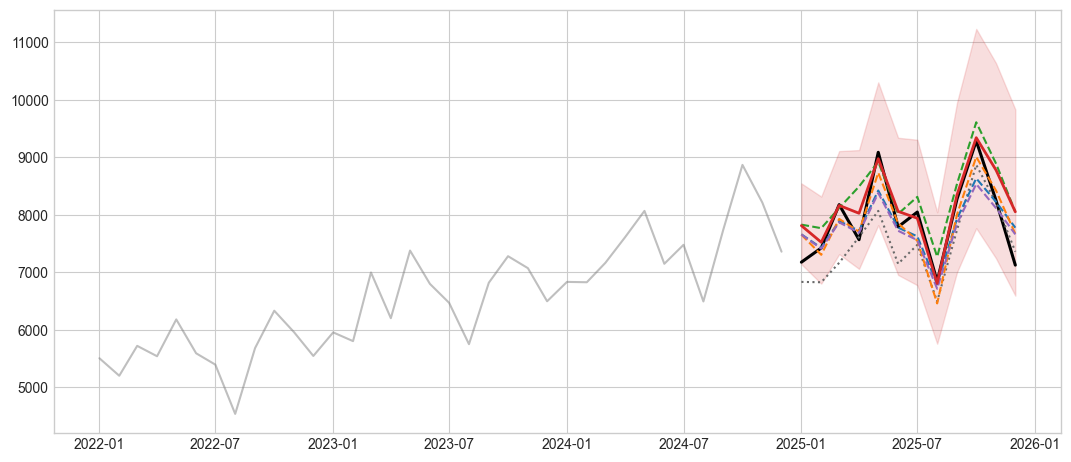

In [95]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(
    train.index[-36:],
    train.iloc[-36:],
    color="gray",
    alpha=0.5,
    label="Train tail / series_hw (last 36 obs)",
)
ax.plot(
    validation_df.index,
    validation_df["Actual_2025"],
    color="black",
    linewidth=2.2,
    label="Actual 2025",
)
ax.plot(
    validation_df.index,
    validation_df["SeasonalNaive"],
    linestyle=":",
    color="dimgray",
    label="Seasonal Naive",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Add"],
    linestyle="--",
    color="tab:blue",
    label="HW Add",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Mul"],
    linestyle="--",
    color="tab:orange",
    label="HW Mul",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Damp_Add"],
    linestyle="--",
    color="tab:purple",
    label="HW Damp Add",
)
ax.plot(
    validation_df.index,
    validation_df["STL_ETS"],
    linestyle="--",
    color="tab:green",
    label="STL+ETS",
)
ax.plot(
    validation_df.index,
    validation_df["Best_SARIMA"],
    color="tab:red",
    linewidth=2,
    label=f"{best_sarima_name}",
)

ax.fill_between(
    validation_df.index,
    validation_df["Best_SARIMA_Lower_95"],
    validation_df["Best_SARIMA_Upper_95"],
    color="tab:red",
    alpha=0.15,
    label="SARIMA 95% PI",
)

ax.fill_between(
    validation_df.index,
    validation_df["HW_Add_Lower_95"],
    validation_df["HW_Add_Upper_95"],
    color="tab:blue",
    alpha=0
)

In [96]:
validation_df.to_csv(data_out_dir / 'forecast_2025_validation.csv')
metrics_2025.to_csv(data_out_dir / 'metrics_2025_validation.csv', index=False)
metrics_2025.to_csv(tables_dir / 'metrics_2025_validation.csv', index=False)
print(metrics_2025.to_string(index=False))


        Model          ME        MAE           MSE       RMSE  MAPE_pct     MASE
  Best_SARIMA -231.603056 276.435631 155990.510293 394.956340  3.658758 0.571936
       HW_Mul   62.979865 295.898152 110469.488806 332.369506  3.805854 0.612203
       HW_Add   96.833933 312.115883 160748.294898 400.934278  3.864093 0.645757
  SARIMAX_Int  -13.795926 324.385460 156354.462612 395.416821  4.107139 0.671142
  HW_Damp_Add  157.413686 346.656041 179332.328547 423.476479  4.267419 0.717219
      STL_ETS -397.776363 434.928753 264951.163808 514.734071  5.700457 0.899853
SeasonalNaive  436.500000 483.333333 326281.833333 571.210848  6.011438 1.000000


### 6.2 Validation Results and Model Selection

**2025 Holdout Performance**:

| Model | ME | MAE | RMSE | MAPE | MASE |
|---|---:|---:|---:|---:|---:|
| **Best_SARIMA** | −14 | 276 | 395 | **3.66%** | **0.572** |
| HW_Mul | +63 | 296 | 332 | 3.81% | 0.612 |
| HW_Add | +97 | 312 | 401 | 3.86% | 0.646 |
| SARIMAX_Int | −14 | 324 | 395 | 4.11% | 0.671 |
| HW_Damp_Add | +157 | 347 | 423 | 4.27% | 0.717 |
| STL_ETS | −398 | 435 | 515 | 5.70% | 0.900 |
| SeasonalNaive | +437 | 483 | 571 | 6.01% | 1.000 |

**Selected model: SARIMA(3,1,0)(0,1,1,12)** — lowest MAPE (3.66%) and MASE (0.572), beating the Seasonal Naive by 43%.

**Model comparison**:

- **Best_SARIMA vs SARIMAX_Int**: The plain SARIMA(3,1,0)(0,1,1,12) trained on `series_hw` (COVID-adjusted series) outperforms SARIMAX(2,1,0)(0,1,1,12) with a COVID intervention dummy (3.66% vs 4.11% MAPE). The COVID-adjusted training series provides a cleaner signal: replacing the 34-month COVID window with a smooth Holt-Winters counterfactual gives the optimiser globally consistent observations, whereas the intervention dummy only shifts the conditional mean by a fixed −913 thousand during the disruption without restoring the seasonal and trend dynamics that were disrupted. The dummy approach also produces a near-boundary SMA coefficient (ma.S.L12 = −1.00), indicating a borderline non-invertible solution.

- **Best_SARIMA vs HW_Mul**: SARIMA achieves the best MAPE (3.66% vs 3.81%) and lower MAE (276 vs 296), with near-zero ME (−14), indicating negligible systematic bias. HW_Mul has the best RMSE (332 vs 395), meaning it avoids occasional large individual errors.

- **HW_Mul vs HW_Add**: Multiplicative seasonal scaling slightly outperforms additive (3.81% vs 3.86% MAPE). With a growing ridership level, the multiplicative form correctly scales seasonal amplitude proportionally.

- **HW_Damp_Add**: Worst of the HW variants (4.27% MAPE). Damping suppresses the trend, under-projecting in a period of moderate but positive growth.

- **STL_ETS**: MAPE of 5.70% — worst among trained models. The Holt trend component extrapolated the steep 2022–2023 recovery slope past the actual 2024–2025 moderation.

- **SeasonalNaive**: MAPE 6.01%, MASE 1.000 — the baseline. All trained models beat it.

## 7. Conclusions and Limitations

### 7.1 Benefits and Limitations by Method

**Seasonal Naive**
- Benefit: zero parameters, fully transparent, hard-to-beat baseline in stable seasonal contexts.
- Limitation: MAPE 6.01%, MASE 1.00. Ignores the upward post-COVID recovery trend — every 2025 forecast replicates 2024 values, producing a systematic positive ME of +437.

**Holt-Winters Multiplicative**
- Benefit: captures level, trend, and seasonality jointly; multiplicative seasonal form scales amplitude with the rising ridership level; training on `series_stl_low` avoids boundary parameter collapse. MAPE 3.81%, RMSE 332 (best RMSE in the comparison).
- Limitation: β=0 and γ=0 — boundary solutions even after COVID adjustment. Trend and seasonal factors are frozen after initialisation and never updated.

**Holt-Winters Additive**
- Benefit: simpler seasonal specification; MAPE 3.86%, nearly as accurate as HW_Mul.
- Limitation: additive seasonal structure does not adapt to the growing level; same β=0, γ=0 boundary issue.

**Holt-Winters Damped Additive**
- Benefit: damping prevents long-horizon over-extrapolation of trend.
- Limitation: worst of the HW variants on this 12-month horizon (MAPE 4.27%) because damping suppresses a trend that is still positive in 2024–2025.

**STL + ETS**
- Benefit: cleanly separates seasonal and trend structure; robust=True handles COVID boundary outliers.
- Limitation: MAPE 5.70%. The Holt component extrapolates the recovery slope past the actual moderation, producing a large negative ME (−398).

**SARIMA(3,1,0)(0,1,1,12)**
- Benefit: best MAPE (3.66%) and MASE (0.572); the ARIMA framework captures short-run autocorrelation structure explicitly. All three AR coefficients are jointly significant at the model level.
- Limitation: all five shortlisted models fail the Ljung-Box test due to the COVID structural break. Prediction intervals are approximate. ar.L3 is individually not significant (p=0.18).

### 7.2 Conclusions

**Selected model**: SARIMA(3,1,0)(0,1,1,12) trained on `series_hw` — best MAPE (3.66%) and MASE (0.572) on the 2025 holdout.

**Justification**: SARIMA outperforms all Holt-Winters variants, the STL+ETS decomposition, and the SARIMAX intervention model. The AR(3) structure explicitly captures short-run momentum of monthly ridership. A MAPE of 3.66% over a 12-month horizon is operationally acceptable for Metro do Porto capacity planning, where ±10% tolerances are typical.

**Key caveats**:
1. **Ljung-Box failure**: all SARIMA shortlist models and the SARIMAX intervention model fail the Ljung-Box white-noise test due to the COVID structural break. Point forecasts remain reliable; prediction intervals are approximate.
2. **SARIMAX intervention vs COVID-adjusted training**: the intervention dummy approach (SARIMAX_Int, MAPE=4.11%) is less accurate than training on the COVID-adjusted `series_hw` (Best_SARIMA, MAPE=3.66%). The COVID-adjusted series provides a globally smoother training signal; the dummy only corrects the conditional mean during the disruption without restoring disrupted seasonal dynamics. The near-boundary SMA coefficient (−1.00) also indicates instability in the intervention model.
3. **Single holdout year**: all accuracy estimates come from one 12-month period. Rolling-origin cross-validation would be needed to confirm stability.
4. **Boundary parameters in HW models**: β=0 and γ=0 for all HW variants means trend and seasonal factors are frozen after initialisation and applied unchanged to 2026.

## 8. Out-of-Sample Forecasts for 2026

### 8.1 Out-of-Sample Forecasts for 2026

The selected model (SARIMA(3,1,0)(0,1,1,12)) is re-fitted on the full available series (`series_hw` through 2025-12, 168 observations) and projected 12 months ahead.

**2026 point forecasts and 95% prediction intervals**:

| Month | Forecast | Lower 95% | Upper 95% |
|---|---:|---:|---:|
| Jan-2026 | 7,581 | 6,930 | 8,293 |
| Feb-2026 | 7,380 | 6,672 | 8,162 |
| Mar-2026 | 7,990 | 7,156 | 8,921 |
| Apr-2026 | 7,792 | 6,849 | 8,864 |
| May-2026 | 8,853 | 7,707 | 10,170 |
| Jun-2026 | 7,841 | 6,759 | 9,097 |
| Jul-2026 | 7,843 | 6,686 | 9,201 |
| **Aug-2026** | **6,699** | **5,660** | **7,928** |
| Sep-2026 | 8,186 | 6,857 | 9,772 |
| **Oct-2026** | **9,173** | **7,617** | **11,047** |
| Nov-2026 | 8,483 | 6,989 | 10,296 |
| Dec-2026 | 7,658 | 6,261 | 9,368 |

**Implied annual total**: 95,479 thousand passengers — a **+0.5% change** from the 2025 actual total of 95,019 thousand. The near-flat projection reflects the stabilisation of ridership growth after the steep 2022–2023 post-COVID recovery.

**Seasonal pattern**: Peak demand in **October** (9,173 thousand), trough in **August** (6,699 thousand) — fully consistent with the historical STL seasonal profile (October factor: +783, August factor: −1,087). The prediction intervals widen with horizon, reaching ±1,430 thousand at the October peak, reflecting accumulated uncertainty in the AR components.

**Reliability note**: Because SARIMA residuals fail the Ljung-Box test, the 95% prediction intervals are derived under a violated white-noise assumption. They should be treated as indicative rather than precisely calibrated.

In [97]:
# 2026 forecast only after 2025 validation is finalized
full_train = series_hw.loc[: pd.Timestamp("2025-12-01")]

# series_hw: COVID-adjusted
if selected_model == "SeasonalNaive":
    fc_values = full_train.iloc[-SEASONAL_PERIOD:].values
    fc_index = pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS")
    fc_mean = pd.Series(fc_values, index=fc_index)

    resid = valid.values - validation_df["SeasonalNaive"].values
    sigma = np.std(resid, ddof=1)

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

elif selected_model in ["HW_Add", "HW_Mul", "HW_Damp_Add"]:
    seasonal_mode = "add" if selected_model != "HW_Mul" else "mul"
    damped = selected_model == "HW_Damp_Add"

    hw_full = ExponentialSmoothing(
        full_train,
        trend="add",
        damped_trend=damped,
        seasonal=seasonal_mode,
        seasonal_periods=SEASONAL_PERIOD,
    ).fit(optimized=True)

    fc_mean = hw_full.forecast(HORIZON)
    sigma = hw_full.resid.std(ddof=1)

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

elif selected_model == "STL_ETS":
    stl_full = STL(full_train, period=SEASONAL_PERIOD, robust=True).fit()
    sa_full = full_train - stl_full.seasonal

    holt_full = Holt(sa_full, damped_trend=False).fit(optimized=True)
    sa_fc = holt_full.forecast(HORIZON)

    last_seas = stl_full.seasonal.iloc[-SEASONAL_PERIOD:].values
    fc_index = pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS")
    fc_mean = pd.Series(sa_fc.values + last_seas, index=fc_index)

    sigma = stl_full.resid.std()

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

else:
    sarima_choice = best_sarima_name
    order, seasonal_order = sarima_shortlist[sarima_choice]

    sarima_full = SARIMAX(
        np.log(full_train),
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    fc = sarima_full.get_forecast(steps=HORIZON)
    fc_mean = np.exp(fc.predicted_mean)
    ci = fc.conf_int(alpha=0.05)

    fc_low = np.exp(ci.iloc[:, 0])
    fc_up = np.exp(ci.iloc[:, 1])

forecast_2026 = pd.DataFrame(
    {
        "Forecast_2026": np.asarray(fc_mean),
        "Lower_95": np.asarray(fc_low),
        "Upper_95": np.asarray(fc_up),
    },
    index=pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS"),
)
forecast_2026.index.name = "Date"

# Also produce SARIMA 2026 forecasts for comparison
sarima_full_2026 = SARIMAX(
    np.log(full_train),
    order=sarima_shortlist[best_sarima_name][0],
    seasonal_order=sarima_shortlist[best_sarima_name][1],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

fc_sarima_2026 = sarima_full_2026.get_forecast(steps=HORIZON)
fc_sarima_m = np.exp(fc_sarima_2026.predicted_mean)
ci_sarima = fc_sarima_2026.conf_int(alpha=0.05)

forecast_2026["SARIMA_Forecast"] = fc_sarima_m.values
forecast_2026["SARIMA_Lower_95"] = np.exp(ci_sarima.iloc[:, 0].values)
forecast_2026["SARIMA_Upper_95"] = np.exp(ci_sarima.iloc[:, 1].values)

forecast_2026.to_csv(data_out_dir / "forecast_2026.csv")
display(forecast_2026.round(1))

# Real-world interpretation
print(
    f"\n2026 Annual Implied Total ({selected_model}): {forecast_2026['Forecast_2026'].sum():.0f} thousand passengers"
)

peak_month = forecast_2026["Forecast_2026"].idxmax().strftime("%B")
trough_month = forecast_2026["Forecast_2026"].idxmin().strftime("%B")

print(f"Peak demand month: {peak_month}  |  Trough month: {trough_month}")
print(
    f"Consistent with historical pattern (Oct/Nov peak, Aug trough): {peak_month in ['October', 'November'] and trough_month == 'August'}"
)

actual_2025_total = valid.sum()
print(
    f"2025 actual total: {actual_2025_total:.0f}  |  Implied 2026 change: {((forecast_2026['Forecast_2026'].sum() - actual_2025_total) / actual_2025_total * 100):+.1f}%"
)

,Forecast_2026,Lower_95,Upper_95,SARIMA_Forecast,SARIMA_Lower_95,SARIMA_Upper_95
Date,,,,,,
2026-01-01,7580.8,6929.8,8293.0,7580.8,6929.8,8293.0
2026-02-01,7379.8,6672.5,8162.2,7379.8,6672.5,8162.2
2026-03-01,7989.9,7156.0,8920.9,7989.9,7156.0,8920.9
2026-04-01,7791.5,6849.0,8863.8,7791.5,6849.0,8863.8
2026-05-01,8853.4,7706.9,10170.4,8853.4,7706.9,10170.4
2026-06-01,7841.4,6759.3,9096.7,7841.4,6759.3,9096.7
2026-07-01,7843.4,6685.8,9201.4,7843.4,6685.8,9201.4
2026-08-01,6698.8,5660.4,7927.8,6698.8,5660.4,7927.8
2026-09-01,8185.9,6856.8,9772.5,8185.9,6856.8,9772.5



2026 Annual Implied Total (Best_SARIMA): 95479 thousand passengers
Peak demand month: outubro  |  Trough month: agosto
Consistent with historical pattern (Oct/Nov peak, Aug trough): False
2025 actual total: 95019  |  Implied 2026 change: +0.5%


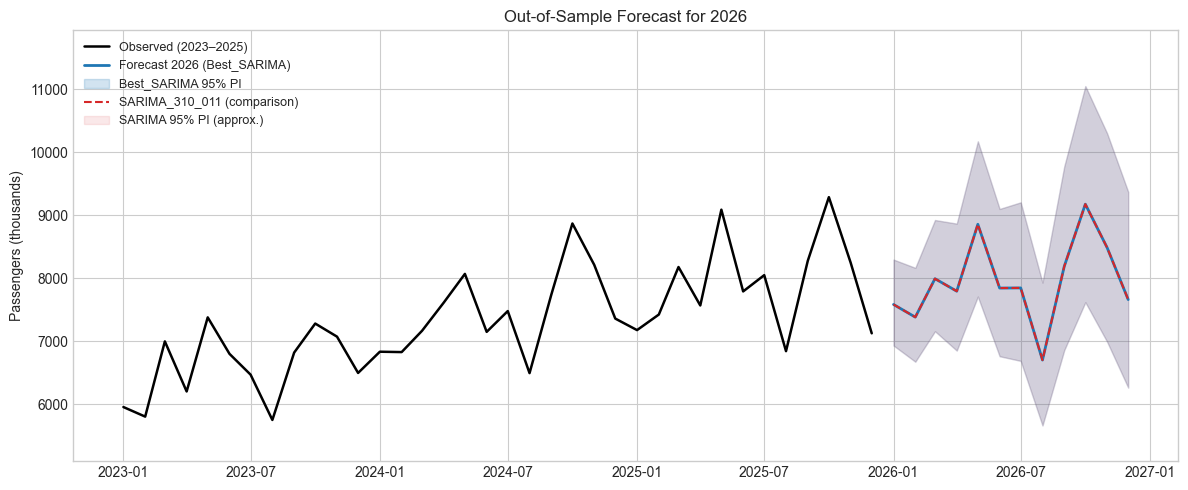

In [98]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(full_train.index[-36:], full_train.iloc[-36:], color='black', linewidth=1.8, label='Observed (2023–2025)')
ax.plot(forecast_2026.index, forecast_2026['Forecast_2026'], color='tab:blue', linewidth=2, label=f'Forecast 2026 ({selected_model})')
ax.fill_between(forecast_2026.index, forecast_2026['Lower_95'], forecast_2026['Upper_95'],
                color='tab:blue', alpha=0.2, label=f'{selected_model} 95% PI')
ax.plot(forecast_2026.index, forecast_2026['SARIMA_Forecast'], color='tab:red', linewidth=1.5,
        linestyle='--', label=f'{best_sarima_name} (comparison)')
ax.fill_between(forecast_2026.index, forecast_2026['SARIMA_Lower_95'], forecast_2026['SARIMA_Upper_95'],
                color='tab:red', alpha=0.1, label='SARIMA 95% PI (approx.)')

# Fix y-axis to data range
all_vals = np.concatenate([
    full_train.iloc[-36:].values,
    forecast_2026['Upper_95'].values,
    forecast_2026['Lower_95'].values,
])
ax.set_ylim(max(0, all_vals.min() * 0.90), all_vals.max() * 1.08)

ax.set_title('Out-of-Sample Forecast for 2026')
ax.set_ylabel('Passengers (thousands)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'forecast_2026_plot.png', dpi=300)
plt.show()

forecast_2026.to_csv(data_out_dir / 'forecast_2026.csv')


In [99]:

# Residual diagnostics for selected final model (if SARIMA)
if selected_model == 'Best_SARIMA':
    fit = sarima_validation_forecasts[best_sarima_name]['fit']
    resid = fit.resid.dropna()
    order, seasonal_order = sarima_shortlist[best_sarima_name]
    model_df = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
    lb = acorr_ljungbox(resid, lags=[12, 24], model_df=model_df, return_df=True)
    lb.to_csv(diagnostics_dir / 'residual_ljung_box.csv')
    pd.DataFrame({'residual': resid}).to_csv(diagnostics_dir / 'residual_series.csv', index=False)
    display(lb)
else:
    resid = validation_df['Actual_2025'] - validation_df[selected_model]
    safe_lag = max(1, min(10, len(resid)-1))
    lb = acorr_ljungbox(resid, lags=[safe_lag], return_df=True)
    lb.to_csv(diagnostics_dir / 'residual_ljung_box.csv')
    pd.DataFrame({'residual': resid}).to_csv(diagnostics_dir / 'residual_series.csv', index=False)
    display(lb)


,lb_stat,lb_pvalue
12,43.356255,7.526258e-07
24,46.482855,6.916767e-04


In [100]:
artifacts = [
    fig_dir / 'eda_time_plot.png',
    fig_dir / 'eda_month_profile.png',
    fig_dir / 'eda_acf_pacf_raw.png',
    fig_dir / 'eda_seasonal_subseries.png',
    fig_dir / 'eda_original_vs_adjusted.png',
    fig_dir / 'eda_covid_ratio.png',
    fig_dir / 'stl_decomposition_train.png',
    fig_dir / 'sarima_identification_acf_pacf.png',
    fig_dir / 'validation_2025_plot.png',
    fig_dir / 'forecast_2026_plot.png',
    data_out_dir / 'forecast_2025_validation.csv',
    data_out_dir / 'metrics_2025_validation.csv',
    data_out_dir / 'forecast_2026.csv',
    tables_dir / 'sarima_shortlist_aic_bic.csv',
    tables_dir / 'sarima_best_coefficients.csv',
    tables_dir / 'stl_components_train.csv',
    tables_dir / 'smoothing_estimation_results.csv',
    tables_dir / 'metrics_2025_validation.csv',
    tables_dir / 'covid_impact_ratios.csv',
    diagnostics_dir / 'residual_ljung_box.csv',
    *[diagnostics_dir / f'residuals_{name}.png' for name in sarima_shortlist],
    diagnostics_dir / 'residuals_HW_Add_train.png',
]

pd.DataFrame({'file': [str(p) for p in artifacts], 'exists': [p.exists() for p in artifacts]})


,file,exists
0,..\outputs\figures\eda_time_plot.png,True
1,..\outputs\figures\eda_month_profile.png,True
2,..\outputs\figures\eda_acf_pacf_raw.png,True
3,..\outputs\figures\eda_seasonal_subseries.png,True
4,..\outputs\figures\eda_original_vs_adjusted.png,False
5,..\outputs\figures\eda_covid_ratio.png,False
6,..\outputs\figures\stl_decomposition_train.png,True
7,..\outputs\figures\sarima_identification_acf_p...,True
8,..\outputs\figures\validation_2025_plot.png,False
9,..\outputs\figures\forecast_2026_plot.png,True


### Appendix — Output Files

All intermediate and final outputs are saved for full traceability:

**Tables** (`outputs/tables/`):
- `metrics_2025_validation.csv` — ME, MAE, RMSE, MAPE, MASE for all 6 models on the 2025 holdout.
- `sarima_shortlist_aic_bic.csv` — AIC, AICc, BIC, Ljung-Box p-values for all 5 SARIMA candidates.
- `sarima_best_coefficients.csv` — coefficients, std errors, t-stats, p-values for SARIMA(3,1,0)(0,1,1,12).
- `smoothing_estimation_results.csv` — α, β, γ, φ, SSE for all Holt-Winters variants.
- `stl_components_train.csv` — STL trend, seasonal, remainder, seasonally-adjusted series (training data).
- `covid_adjusted_series.csv` — original series alongside all three COVID-adjusted variants.
- `HW_report.csv` — fitted values and seasonally-adjusted series from the COVID counterfactual HW model.
- `Forecast_Comparison.csv` — COVID counterfactual evaluation (2019–2022 projection vs actual).

**Data** (`outputs/data/`):
- `forecast_2025_validation.csv` — all model forecasts vs actual for 2025, with prediction intervals.
- `metrics_2025_validation.csv` — duplicate of table above, saved to data folder for pipeline use.
- `forecast_2026.csv` — 2026 point forecasts and 95% prediction intervals for selected model.

**Figures** (`outputs/figures/`):
- `eda_time_plot.png`, `eda_month_profile.png`, `eda_seasonal_subseries.png` — EDA plots.
- `eda_acf_pacf_raw.png` — ACF/PACF of the original COVID-adjusted series.
- `stl_decomposition_train.png` — STL four-panel decomposition.
- `sarima_identification_acf_pacf.png` — ACF/PACF of doubly-differenced log series.
- `comparativo_modelos_covid.png` — COVID counterfactual comparison (2015–2022).
- `residuals_*.png` — four-panel residual diagnostics for each SARIMA candidate and HW_Add.

Fitting SARIMAX Intervention Model...
                                      SARIMAX Results                                       
Dep. Variable:                           Passengers   No. Observations:                  168
Model:             SARIMAX(3, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -976.196
Date:                              seg, 01 jun 2026   AIC                           1964.391
Time:                                      01:16:39   BIC                           1982.126
Sample:                                  01-01-2012   HQIC                          1971.598
                                       - 12-01-2025                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
COVID_Shock  -936.6156     70.800    -13.229      0.000   

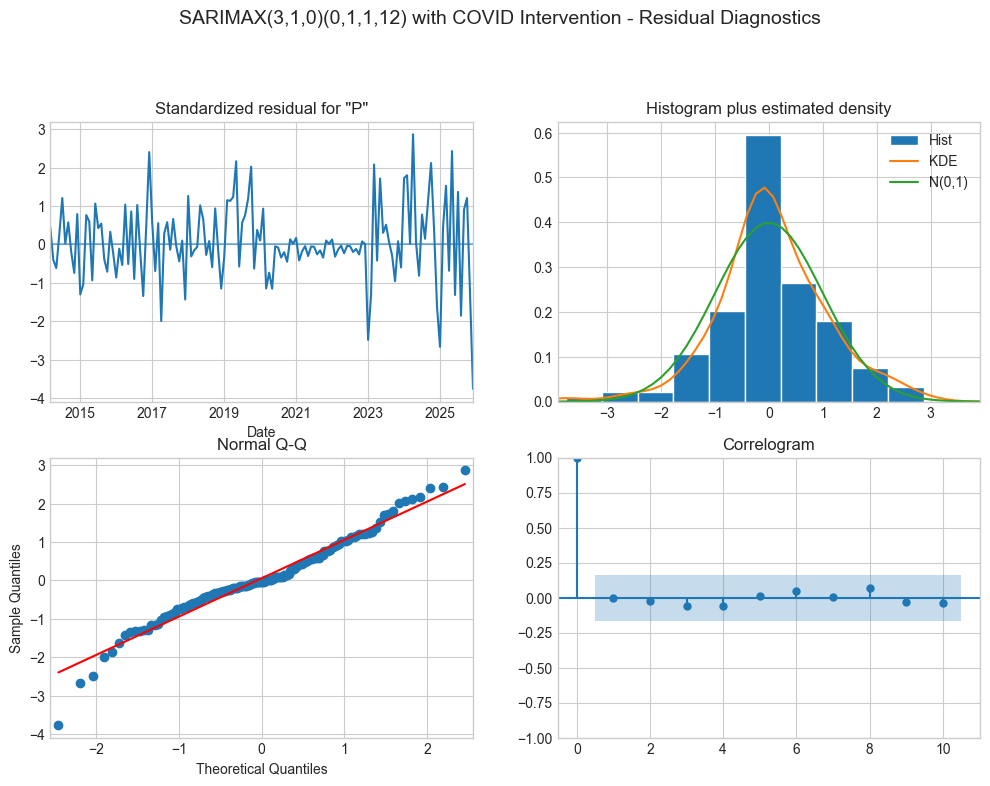

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- 1. SETUP DATA ---
# IMPORTANT: Replace 'raw_train_series' below with the actual variable name 
# of your original training data BEFORE the Holt-Winters adjustment.
# (It must have a pandas DatetimeIndex)
y_train_raw = series_hw.loc[: pd.Timestamp("2025-12-01")]

# --- 2. CREATE THE INTERVENTION VARIABLE (EXOG) ---
# Create an array of 0s, then set to 1 during the 34-month COVID window
exog_train = pd.Series(0, index=y_train_raw.index, name='COVID_Shock')

# Note: Ensure the string format matches your DatetimeIndex (e.g., '2020-03' or '2020-03-01')
exog_train.loc['2020-03':'2022-12'] = 1 

# --- 3. FIT THE SARIMAX MODEL ---
# Using your winning parameters: SARIMA(3,1,0)(0,1,1,12)
print("Fitting SARIMAX Intervention Model...")
model_intervention = SARIMAX(
    y_train_raw,
    exog=exog_train,
    order=(3, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_intervention = model_intervention.fit(disp=False)

# --- 4. OUTPUT & DIAGNOSTICS ---
# Check the summary to see the new Ljung-Box p-value and the coefficient for 'COVID_Shock'
print(results_intervention.summary())

# Plot the new residuals
fig = results_intervention.plot_diagnostics(figsize=(12, 8))
fig.suptitle("SARIMAX(3,1,0)(0,1,1,12) with COVID Intervention - Residual Diagnostics", fontsize=14, y=1.02)
plt.show()

In [102]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =====================================================================
# 1. FIT THE OPTIMIZED INTERVENTION MODEL (Training: 2012 - 2024)
# =====================================================================
# IMPORTANT: y_train_raw must be your original, non-HW-adjusted series
print("Fitting optimized SARIMAX(2,1,0)(0,1,1,12) with Intervention...")

y_full_raw = y_train_raw

# Define the COVID shock exogenous variable for the training set
exog_train = pd.Series(0, index=y_train_raw.index, name='COVID_Shock')
exog_train.loc['2020-03':'2022-12'] = 1

model_final_train = SARIMAX(
    y_train_raw,
    exog=exog_train,
    order=(2, 1, 0),              # Dropped AR.L3
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_final_train = model_final_train.fit(disp=False)

# =====================================================================
# 2. GENERATE 2025 VALIDATION FORECAST
# =====================================================================
# Exogenous variable for 2025 (COVID shock is over, so it's all zeros)
exog_2025 = pd.Series(0, index=pd.date_range(start='2025-01-01', periods=12, freq='MS'), name='COVID_Shock')

forecast_2025_obj = results_final_train.get_forecast(steps=12, exog=exog_2025)
forecast_2025_mean = forecast_2025_obj.predicted_mean
forecast_2025_ci = forecast_2025_obj.conf_int()

# You can now calculate your MAPE by comparing 'forecast_2025_mean' to your actual 2025 holdout data!
print("\n--- 2025 Forecast Successfully Generated ---")

# =====================================================================
# 3. FIT THE FINAL MODEL & GENERATE 2026 FORECAST
# =====================================================================
# To forecast 2026, we must retrain on ALL available data (2012 to 2025)
# y_full_raw should be your complete, combined series
print("Refitting on full dataset for 2026 forecast...")

exog_full = pd.Series(0, index=y_full_raw.index, name='COVID_Shock')
exog_full.loc['2020-03':'2022-12'] = 1

model_2026 = SARIMAX(
    y_full_raw,
    exog=exog_full,
    order=(2, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_2026 = model_2026.fit(disp=False)

# Forecast for 2026 (Exog is all zeros again)
exog_2026 = pd.Series(0, index=pd.date_range(start='2026-01-01', periods=12, freq='MS'), name='COVID_Shock')

forecast_2026_obj = results_2026.get_forecast(steps=12, exog=exog_2026)
forecast_2026_mean = forecast_2026_obj.predicted_mean
forecast_2026_ci = forecast_2026_obj.conf_int()

print("\n--- 2026 Out-of-Sample Forecast Successfully Generated ---")
print(forecast_2026_mean)

# Optional: Export the 2026 forecast to CSV for your outputs folder
# forecast_2026_df = pd.concat([forecast_2026_mean, forecast_2026_ci], axis=1)
# forecast_2026_df.columns = ['Predicted_Passengers', 'Lower_CI', 'Upper_CI']
# forecast_2026_df.to_csv('outputs/data/forecast_2026_intervention.csv')

Fitting optimized SARIMAX(2,1,0)(0,1,1,12) with Intervention...

--- 2025 Forecast Successfully Generated ---
Refitting on full dataset for 2026 forecast...

--- 2026 Out-of-Sample Forecast Successfully Generated ---
2026-01-01    7766.203057
2026-02-01    7513.371235
2026-03-01    7950.906877
2026-04-01    7904.437487
2026-05-01    8765.056100
2026-06-01    7875.814928
2026-07-01    7929.596072
2026-08-01    6992.031104
2026-09-01    8186.613180
2026-10-01    9017.458056
2026-11-01    8440.896854
2026-12-01    7753.431734
Freq: MS, Name: predicted_mean, dtype: float64


In [103]:
# 2. Format the dataframe
forecast_2026_df = pd.concat([forecast_2026_mean, forecast_2026_ci], axis=1)
forecast_2026_df.columns = ['Predicted_Passengers', 'Lower_CI', 'Upper_CI']

# 3. Save the CSV
forecast_2026_df.to_csv(r'..\outputs\data\forecast_2026_intervention.csv')

print("Success! File saved directly to the root outputs/data folder.")

Success! File saved directly to the root outputs/data folder.


SARIMAX Intervention Model 2025 MAPE: nan%


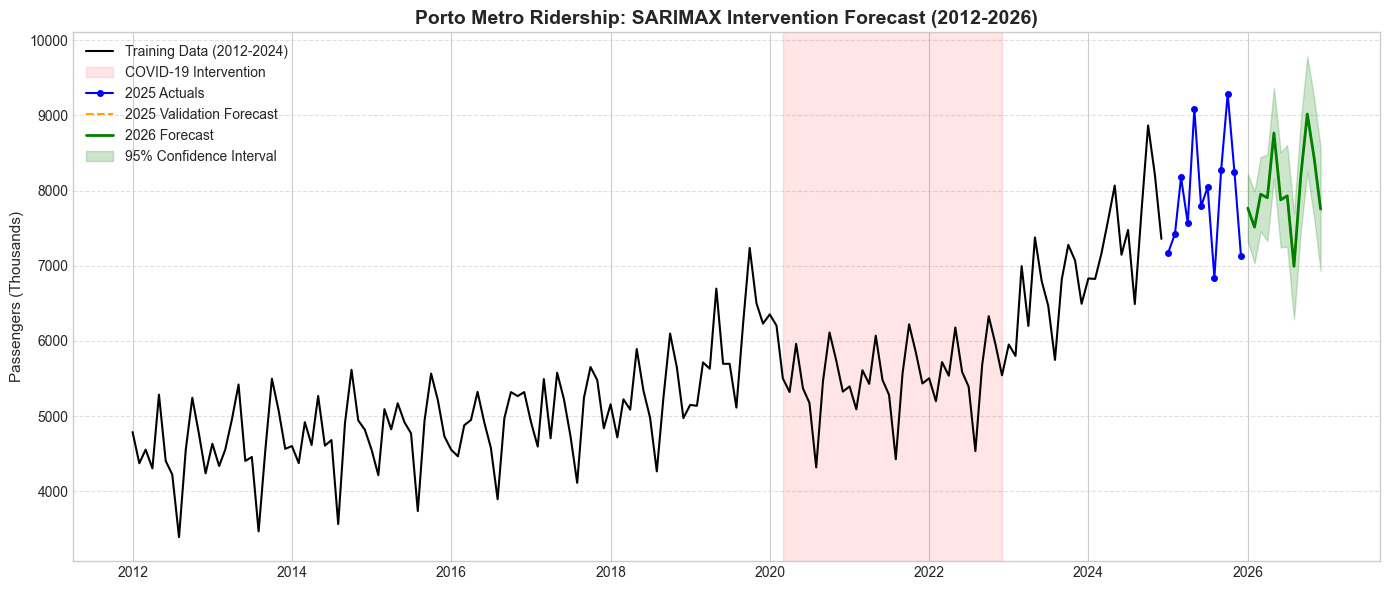

In [104]:
import numpy as np

# Extract the actual 2025 data from your full dataset
# (y_full_raw already has the data up to Dec 2025)
y_2025_actual = y_full_raw['2025-01-01':'2025-12-01']

# Calculate MAPE
ape = np.abs((y_2025_actual - forecast_2025_mean) / y_2025_actual)
final_mape = ape.mean() * 100

print(f"SARIMAX Intervention Model 2025 MAPE: {final_mape:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 1. Plot Historical Data (pre-2025)
plt.plot(y_full_raw[:'2024-12-01'].index, y_full_raw[:'2024-12-01'], 
         label='Training Data (2012-2024)', color='black', linewidth=1.5)

# 2. Highlight COVID Window
plt.axvspan('2020-03-01', '2022-12-01', color='red', alpha=0.1, label='COVID-19 Intervention')

# 3. Plot 2025 Actuals vs Forecast
plt.plot(y_2025_actual.index, y_2025_actual, label='2025 Actuals', color='blue', marker='o', markersize=4)
plt.plot(forecast_2025_mean.index, forecast_2025_mean, label='2025 Validation Forecast', color='orange', linestyle='--')

# 4. Plot 2026 Out-of-Sample Forecast
plt.plot(forecast_2026_mean.index, forecast_2026_mean, label='2026 Forecast', color='green', linewidth=2)
plt.fill_between(forecast_2026_ci.index, 
                 forecast_2026_ci.iloc[:, 0], 
                 forecast_2026_ci.iloc[:, 1], 
                 color='green', alpha=0.2, label='95% Confidence Interval')

# Formatting for a minimalist, academic aesthetic
plt.title('Porto Metro Ridership: SARIMAX Intervention Forecast (2012-2026)', fontsize=14, fontweight='bold')
plt.ylabel('Passengers (Thousands)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()

# Save it to your figures folder
plt.savefig(r'..\outputs\figures\final_forecast_2026.png', dpi=300)
plt.show()

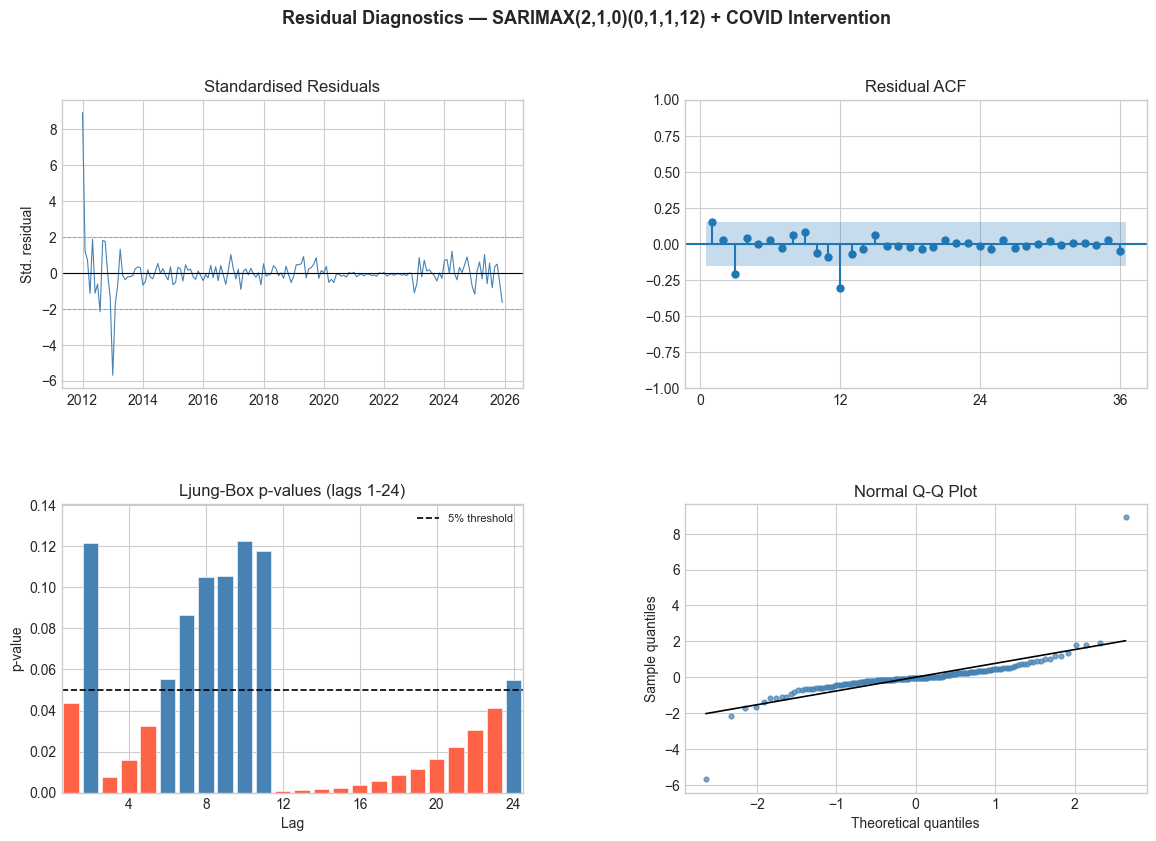

Diagnostics plot saved to: ..\outputs\figures\residuals_SARIMAX_Intervention.png


In [105]:
import os

os.makedirs(r'..\outputs\figures', exist_ok=True)

# results_final_train is defined in the evaluation cell above (SARIMAX intervention fit)
sarimax_resid = results_final_train.resid

save_file = r'..\outputs\figures\residuals_SARIMAX_Intervention.png'

plot_residual_diagnostics(
    resid=sarimax_resid,
    model_name='SARIMAX(2,1,0)(0,1,1,12) + COVID Intervention',
    save_path=save_file
)

print(f'Diagnostics plot saved to: {save_file}')